Using device: cuda
pred_n std 0.8449 | gt_norm std 1.0326


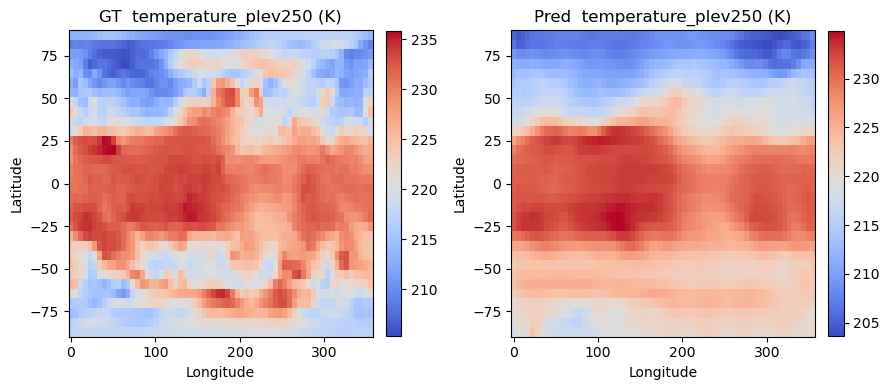

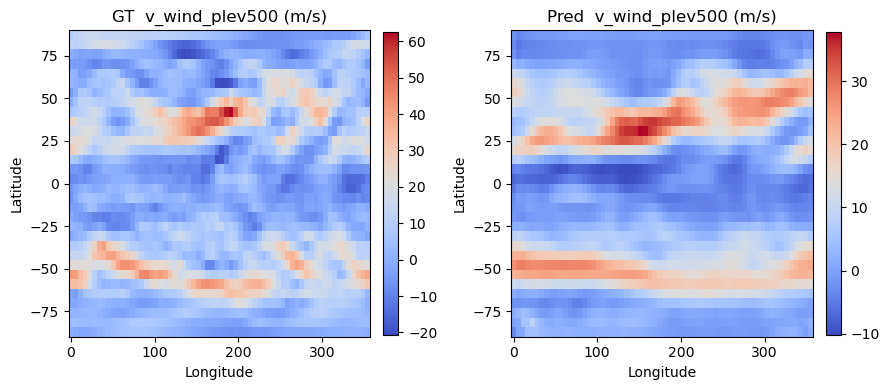

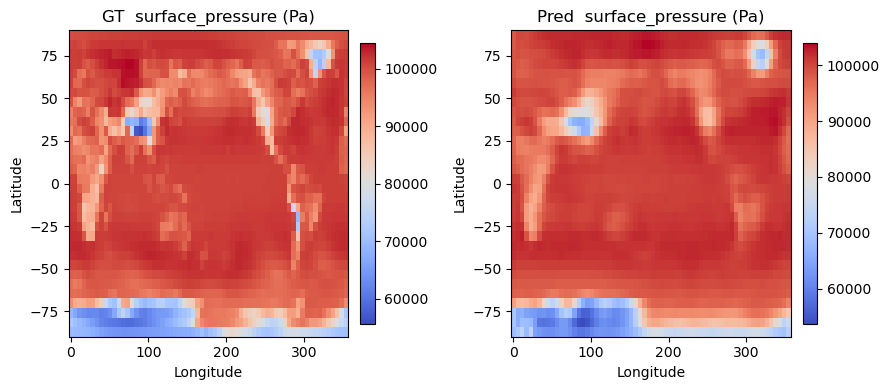

In [31]:
import os, sys, torch, numpy as np, xarray as xr, matplotlib.pyplot as plt
BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "checkpoints/fuxi_epoch028.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
HISTORY_STEPS = 2
SAMPLE = 0
PLOT_NORM = False  # False -> physical units; True -> normalized (z-score)

PRESSURE_LEVELS = [250,500,850]  # hPa
PRESSURE_VARS = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS  = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]
VIEW = {
    "temperature_plev250 (K)":0,
    "v_wind_plev500 (m/s)":7,
    "surface_pressure (Pa)":19,
}

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[PRESSURE_VARS[0]].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def stack(ds):
    swap = needs_swap(ds)
    arr=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = ds[v].sel(level=lvl).values
            if swap: val = np.swapaxes(val, -2, -1)  # (lat, lon)
            arr.append(val)
    for v in SURFACE_VARS:
        val = ds[v].values
        if swap: val = np.swapaxes(val, -2, -1)
        arr.append(val)
    return np.stack(arr, 0)

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    tr = xr.open_dataset(TRAIN)
    train_all = stack(tr)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()

    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    if lat_desc:
        lat = lat[::-1]
    LON, LAT = np.meshgrid(lon, lat)

    swap = needs_swap(te)

    hist=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: val = np.swapaxes(val, -2, -1)
            if lat_desc: val = val[..., ::-1, :]
            hist.append(val)
    for v in SURFACE_VARS:
        val = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: val = np.swapaxes(val, -2, -1)
        if lat_desc: val = val[..., ::-1, :]
        hist.append(val)
    hist = np.stack(hist, 0)

    gt=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = te[v].sel(level=lvl).values[SAMPLE+HISTORY_STEPS]
            if swap: val = np.swapaxes(val, -2, -1)
            if lat_desc: val = val[..., ::-1, :]
            gt.append(val)
    for v in SURFACE_VARS:
        val = te[v].values[SAMPLE+HISTORY_STEPS]
        if swap: val = np.swapaxes(val, -2, -1)
        if lat_desc: val = val[..., ::-1, :]
        gt.append(val)
    gt = np.stack(gt, 0)
    te.close()

    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=256,
        encoder_dims=(256,320,384),
        swin_depths=(4,4,8),
        swin_heads=(4,8,16),
        swin_window_size=8,
        drop_path_rate=0.1,
        input_height=32, input_width=64,
    ).to(device)

    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    mean_s = mean.squeeze(1); std_s = std.squeeze(1)
    hist_n = (hist - mean_s[:,None]) / std_s[:,None]
    h = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(h)
    pred_n = out[0] if isinstance(out,(list,tuple)) else out
    if pred_n.ndim == 4 and pred_n.shape[0] == 1:
        pred_n = pred_n.squeeze(0)
    pred_n = pred_n.detach().cpu().numpy()
    gt_norm = (gt - mean_s) / std_s
    pred_phys = pred_n * std_s + mean_s
    gt_phys   = gt

    print(f"pred_n std {pred_n.std():.4f} | gt_norm std {gt_norm.std():.4f}")

    for name, idx in VIEW.items():
        gt_src = gt_norm if PLOT_NORM else gt_phys
        pr_src = pred_n  if PLOT_NORM else pred_phys
        gt_i = gt_src[idx]
        pr_i = pr_src[idx]
        plt.figure(figsize=(9,4))
        plt.subplot(1,2,1)
        pcm = plt.pcolormesh(LON, LAT, gt_i, shading="auto", cmap="coolwarm")
        plt.title(f"GT {'(norm)' if PLOT_NORM else ''} {name}")
        plt.colorbar(pcm, fraction=0.046, pad=0.04)
        plt.xlabel("Longitude"); plt.ylabel("Latitude")
        plt.subplot(1,2,2)
        pcm = plt.pcolormesh(LON, LAT, pr_i, shading="auto", cmap="coolwarm")
        plt.title(f"Pred {'(norm)' if PLOT_NORM else ''} {name}")
        plt.colorbar(pcm, fraction=0.046, pad=0.04)
        plt.xlabel("Longitude"); plt.ylabel("Latitude")
        plt.tight_layout(); plt.show()

if __name__ == "__main__":
    main()

Using device: cuda
pred_n std 0.9970 | gt_norm std 1.0326


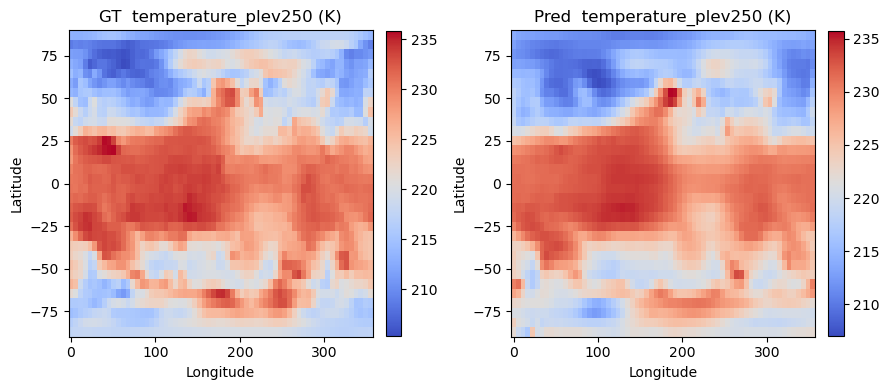

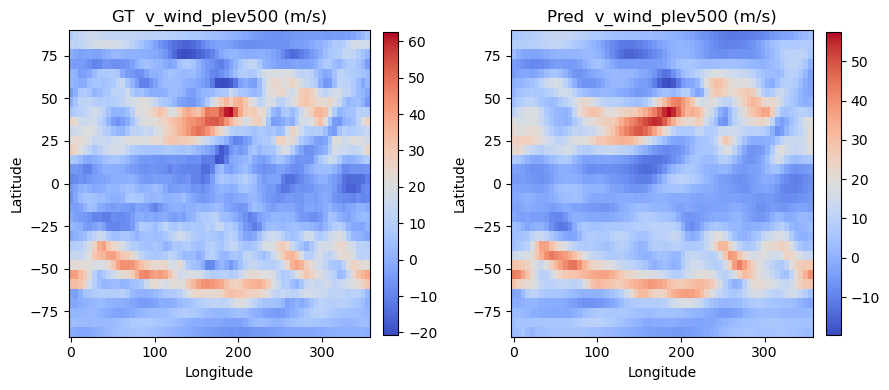

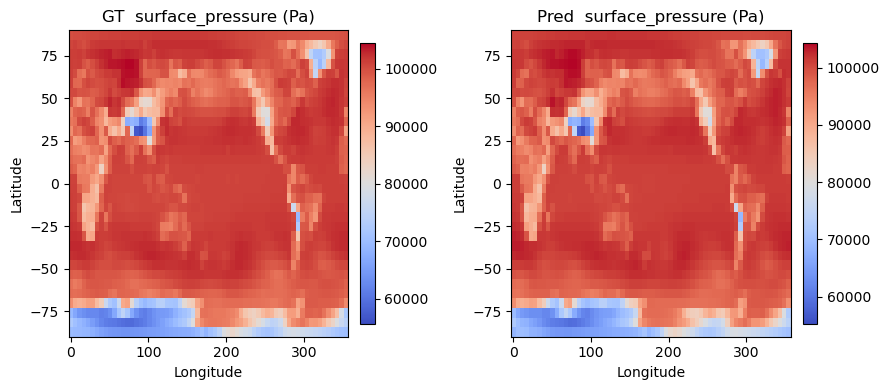

In [33]:
import os, sys, torch, numpy as np, xarray as xr, matplotlib.pyplot as plt
BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")  # change epoch if desired
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
HISTORY_STEPS = 2
SAMPLE = 0
PLOT_NORM = False  # False -> physical units; True -> normalized

PRESSURE_LEVELS = [250,500,850]  # hPa
PRESSURE_VARS = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS  = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]
VIEW = {
    "temperature_plev250 (K)":0,
    "v_wind_plev500 (m/s)":7,
    "surface_pressure (Pa)":19,
}

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[PRESSURE_VARS[0]].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def stack(ds):
    swap = needs_swap(ds)
    arr=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = ds[v].sel(level=lvl).values
            if swap: val = np.swapaxes(val, -2, -1)  # (lat, lon)
            arr.append(val)
    for v in SURFACE_VARS:
        val = ds[v].values
        if swap: val = np.swapaxes(val, -2, -1)
        arr.append(val)
    return np.stack(arr, 0)

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    tr = xr.open_dataset(TRAIN)
    train_all = stack(tr)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()

    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    if lat_desc:
        lat = lat[::-1]
    LON, LAT = np.meshgrid(lon, lat)
    swap = needs_swap(te)

    hist=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: val = np.swapaxes(val, -2, -1)
            if lat_desc: val = val[..., ::-1, :]
            hist.append(val)
    for v in SURFACE_VARS:
        val = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: val = np.swapaxes(val, -2, -1)
        if lat_desc: val = val[..., ::-1, :]
        hist.append(val)
    hist = np.stack(hist, 0)

    gt=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = te[v].sel(level=lvl).values[SAMPLE+HISTORY_STEPS]
            if swap: val = np.swapaxes(val, -2, -1)
            if lat_desc: val = val[..., ::-1, :]
            gt.append(val)
    for v in SURFACE_VARS:
        val = te[v].values[SAMPLE+HISTORY_STEPS]
        if swap: val = np.swapaxes(val, -2, -1)
        if lat_desc: val = val[..., ::-1, :]
        gt.append(val)
    gt = np.stack(gt, 0)
    te.close()

    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=512,
        encoder_dims=(512,768,960),
        swin_depths=(3,4,6),
        swin_heads=(8,12,15),
        swin_window_size=8,
        drop_path_rate=0.15,
        input_height=32, input_width=64,
    ).to(device)

    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    mean_s = mean.squeeze(1); std_s = std.squeeze(1)
    hist_n = (hist - mean_s[:,None]) / std_s[:,None]
    h = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
    with torch.no_grad():
        out = model(h)
    pred_n = out[0] if isinstance(out,(list,tuple)) else out
    if pred_n.ndim == 4 and pred_n.shape[0] == 1:
        pred_n = pred_n.squeeze(0)
    pred_n = pred_n.detach().cpu().numpy()
    gt_norm = (gt - mean_s) / std_s
    pred_phys = pred_n * std_s + mean_s
    gt_phys   = gt

    print(f"pred_n std {pred_n.std():.4f} | gt_norm std {gt_norm.std():.4f}")

    for name, idx in VIEW.items():
        gt_src = gt_norm if PLOT_NORM else gt_phys
        pr_src = pred_n  if PLOT_NORM else pred_phys
        gt_i = gt_src[idx]
        pr_i = pr_src[idx]
        plt.figure(figsize=(9,4))
        plt.subplot(1,2,1)
        pcm = plt.pcolormesh(LON, LAT, gt_i, shading="auto", cmap="coolwarm")
        plt.title(f"GT {'(norm)' if PLOT_NORM else ''} {name}")
        plt.colorbar(pcm, fraction=0.046, pad=0.04)
        plt.xlabel("Longitude"); plt.ylabel("Latitude")
        plt.subplot(1,2,2)
        pcm = plt.pcolormesh(LON, LAT, pr_i, shading="auto", cmap="coolwarm")
        plt.title(f"Pred {'(norm)' if PLOT_NORM else ''} {name}")
        plt.colorbar(pcm, fraction=0.046, pad=0.04)
        plt.xlabel("Longitude"); plt.ylabel("Latitude")
        plt.tight_layout(); plt.show()

if __name__ == "__main__":
    main()

Using device: cuda
pred_n std 0.9970 | gt_norm std 1.0326


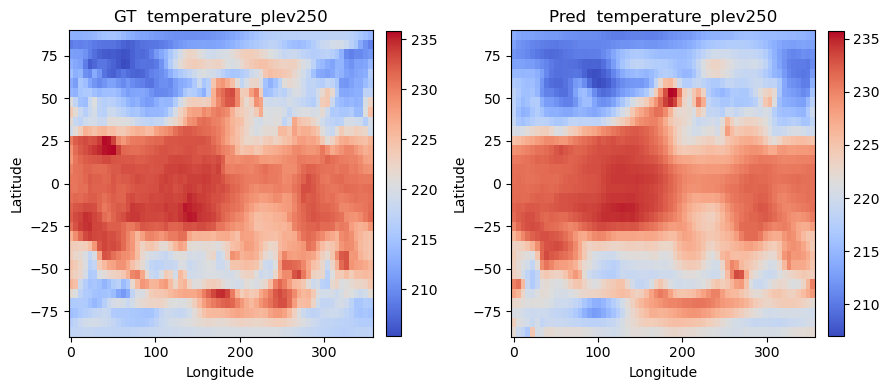

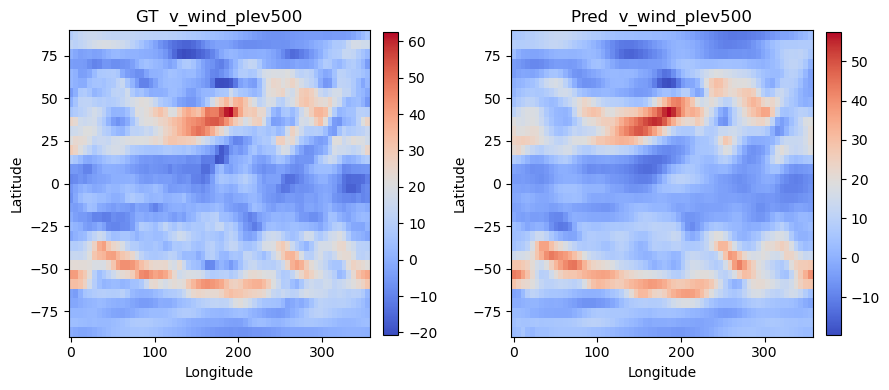

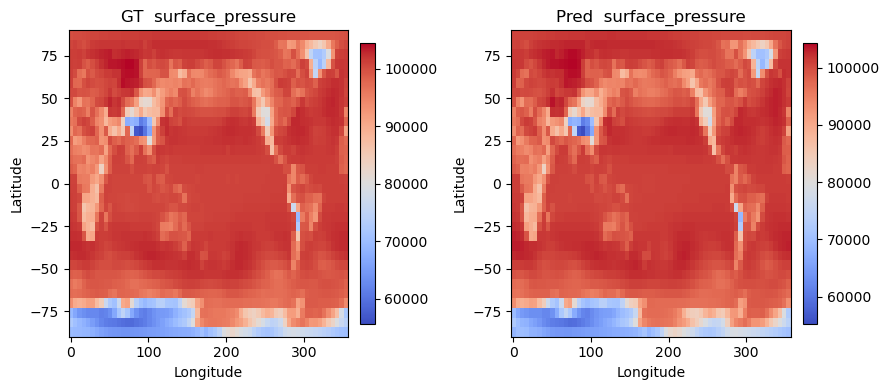

In [34]:
import os, sys, torch, numpy as np, xarray as xr, matplotlib.pyplot as plt
BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
HISTORY_STEPS = 2
SAMPLE = 0
PLOT_NORM = False  # False -> physical units; True -> normalized

PRESSURE_LEVELS = [250,500,850]
PRESSURE_VARS = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS  = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]
VIEW = {
    "temperature_plev250":0,
    "v_wind_plev500":7,
    "surface_pressure":19,
}

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[PRESSURE_VARS[0]].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def stack(ds):
    swap = needs_swap(ds)
    arr=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = ds[v].sel(level=lvl).values
            if swap: val = np.swapaxes(val, -2, -1)
            arr.append(val)
    for v in SURFACE_VARS:
        val = ds[v].values
        if swap: val = np.swapaxes(val, -2, -1)
        arr.append(val)
    return np.stack(arr, 0), swap

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# stats
tr = xr.open_dataset(TRAIN)
train_all, _ = stack(tr)
mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
tr.close()

te = xr.open_dataset(TEST)
lat = te["latitude" if "latitude" in te.dims else "lat"].values
lon = te["longitude" if "longitude" in te.dims else "lon"].values
lat_desc = lat[0] > lat[-1]
if lat_desc: lat = lat[::-1]
LON, LAT = np.meshgrid(lon, lat)
swap = needs_swap(te)

# build sample
hist=[]; gt=[]
for v in PRESSURE_VARS:
    for lvl in PRESSURE_LEVELS:
        h = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
        g = te[v].sel(level=lvl).values[SAMPLE+HISTORY_STEPS]
        if swap: h, g = np.swapaxes(h, -2, -1), np.swapaxes(g, -2, -1)
        if lat_desc: h, g = h[..., ::-1, :], g[..., ::-1, :]
        hist.append(h); gt.append(g)
for v in SURFACE_VARS:
    h = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
    g = te[v].values[SAMPLE+HISTORY_STEPS]
    if swap: h, g = np.swapaxes(h, -2, -1), np.swapaxes(g, -2, -1)
    if lat_desc: h, g = h[..., ::-1, :], g[..., ::-1, :]
    hist.append(h); gt.append(g)
hist = np.stack(hist, 0)
gt   = np.stack(gt, 0)
te.close()

# model
model = FuXiModel(
    in_channels=20, out_channels=20,
    embed_dim=512,
    encoder_dims=(512,768,960),
    swin_depths=(3,4,6),
    swin_heads=(8,12,15),
    swin_window_size=8,
    drop_path_rate=0.15,
    input_height=32, input_width=64,
).to(device)
sd = torch.load(CKPT, map_location=device)["model_state"]
sd = {k.replace("module.","",1): v for k,v in sd.items()}
model.load_state_dict(sd)
model.eval()

mean_s = mean.squeeze(1); std_s = std.squeeze(1)
hist_n = (hist - mean_s[:,None]) / std_s[:,None]
h = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
with torch.no_grad():
    out = model(h)
pred_n = out[0] if isinstance(out,(list,tuple)) else out
pred_n = pred_n.squeeze(0).detach().cpu().numpy()
gt_norm = (gt - mean_s) / std_s
pred_phys = pred_n * std_s + mean_s
gt_phys   = gt

print(f"pred_n std {pred_n.std():.4f} | gt_norm std {gt_norm.std():.4f}")

for name, idx in VIEW.items():
    gt_i = gt_norm[idx] if PLOT_NORM else gt_phys[idx]
    pr_i = pred_n[idx]  if PLOT_NORM else pred_phys[idx]
    plt.figure(figsize=(9,4))
    plt.subplot(1,2,1)
    pcm = plt.pcolormesh(LON, LAT, gt_i, shading="auto", cmap="coolwarm")
    plt.title(f"GT {'(norm)' if PLOT_NORM else ''} {name}")
    plt.colorbar(pcm, fraction=0.046, pad=0.04)
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.subplot(1,2,2)
    pcm = plt.pcolormesh(LON, LAT, pr_i, shading="auto", cmap="coolwarm")
    plt.title(f"Pred {'(norm)' if PLOT_NORM else ''} {name}")
    plt.colorbar(pcm, fraction=0.046, pad=0.04)
    plt.xlabel("Longitude"); plt.ylabel("Latitude")
    plt.tight_layout(); plt.show()

Using device: cuda
Step 1: RMSE_norm mean=0.275, ACC mean=0.951
Step 2: RMSE_norm mean=0.312, ACC mean=0.939
Step 3: RMSE_norm mean=0.364, ACC mean=0.919
Step 4: RMSE_norm mean=0.403, ACC mean=0.900
Step 5: RMSE_norm mean=0.436, ACC mean=0.882


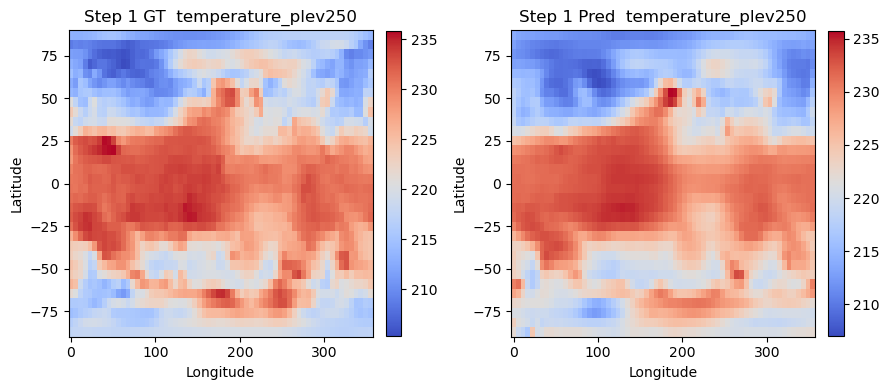

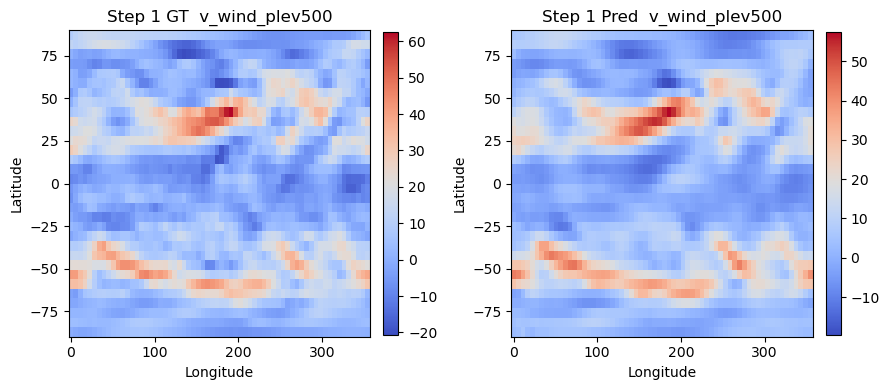

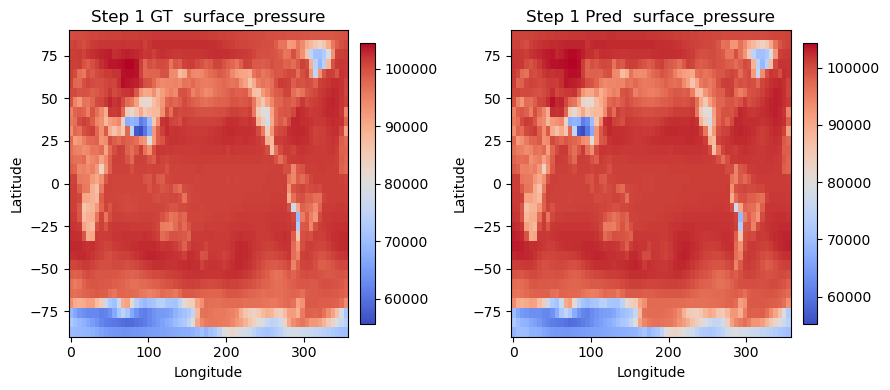

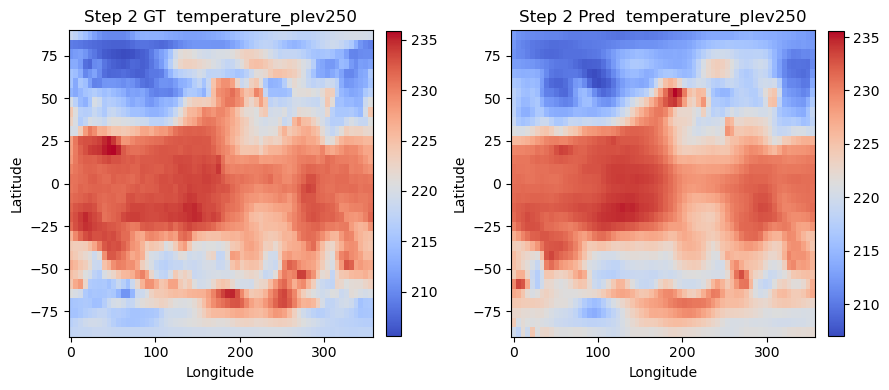

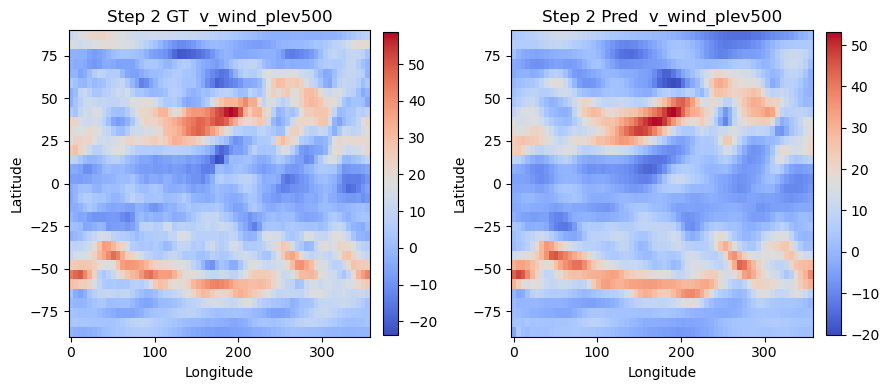

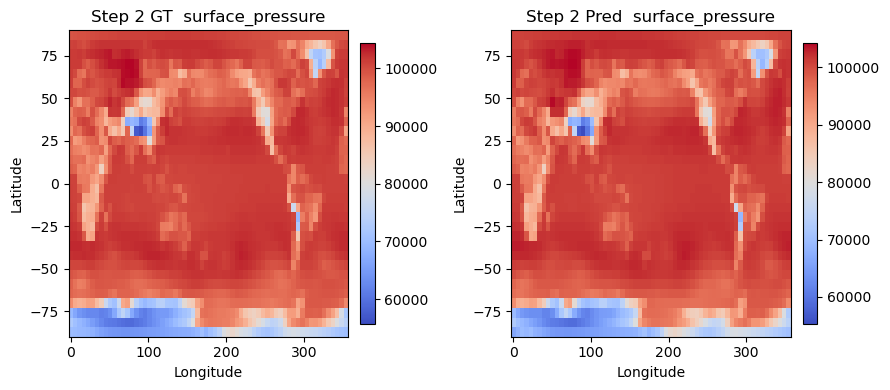

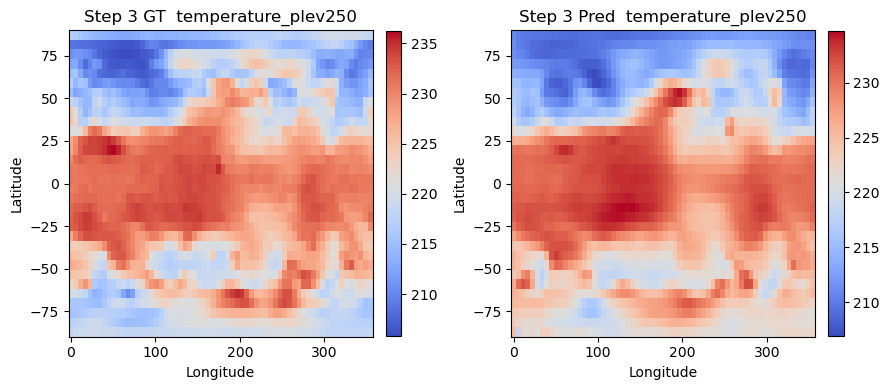

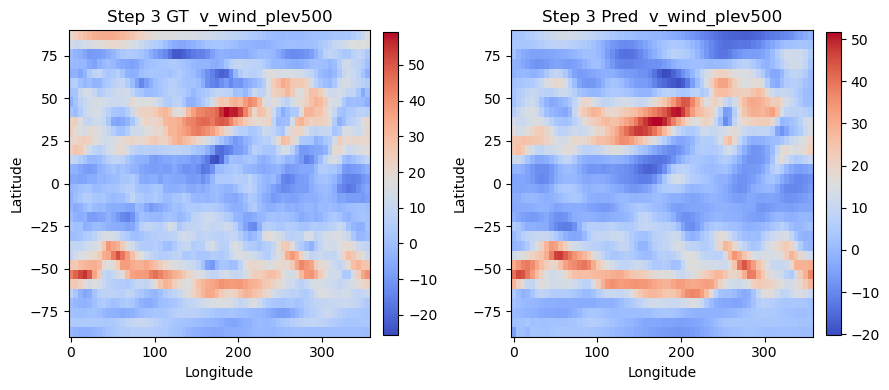

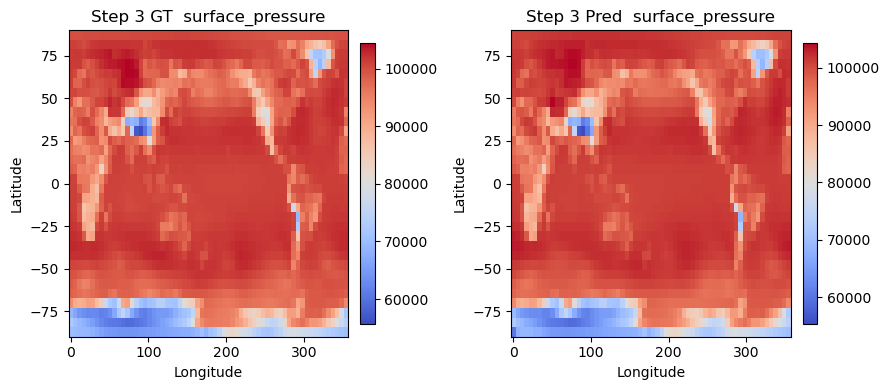

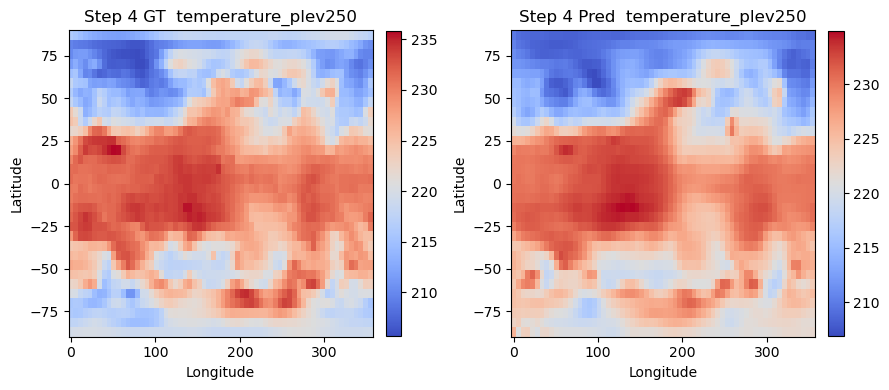

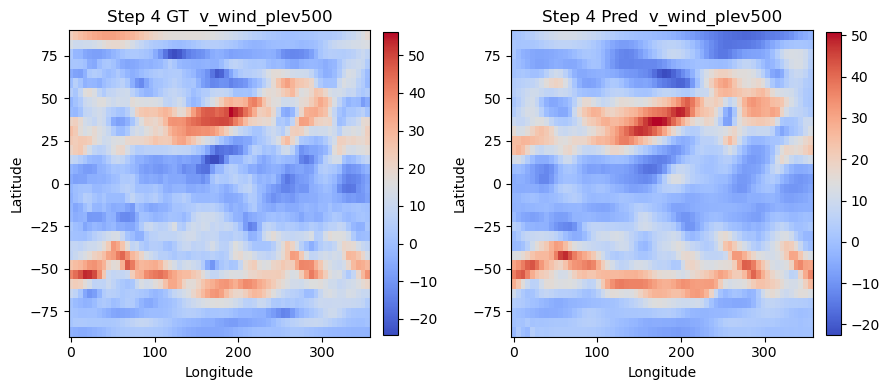

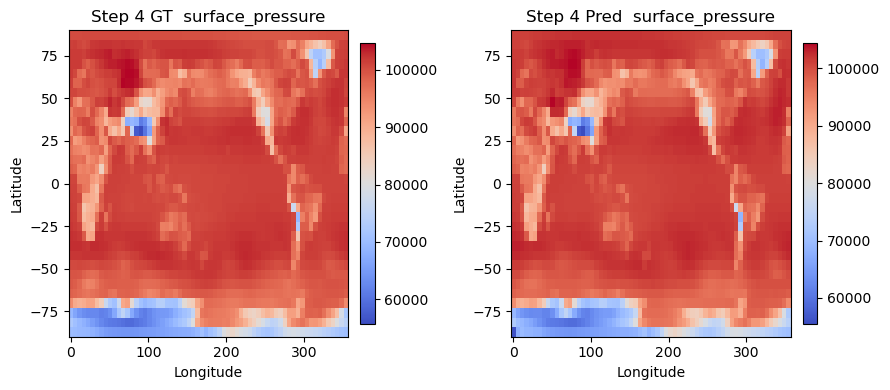

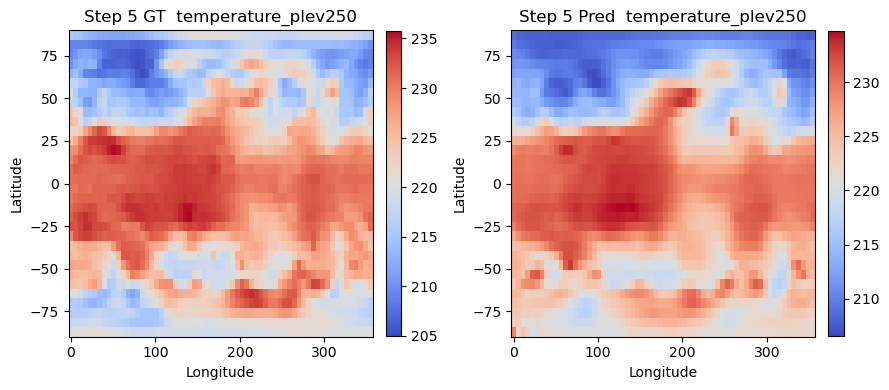

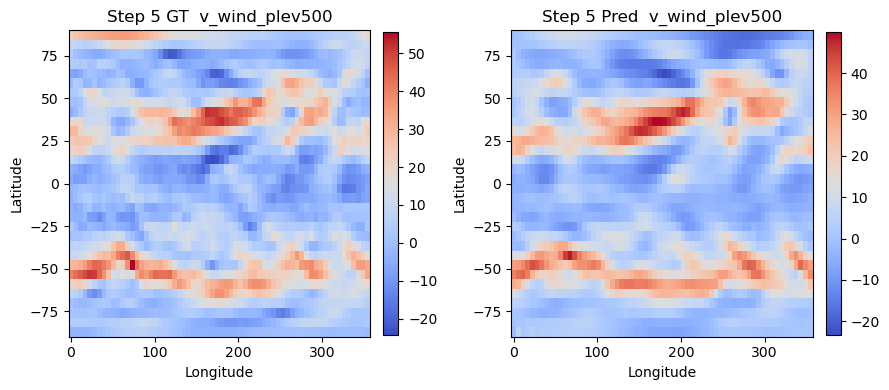

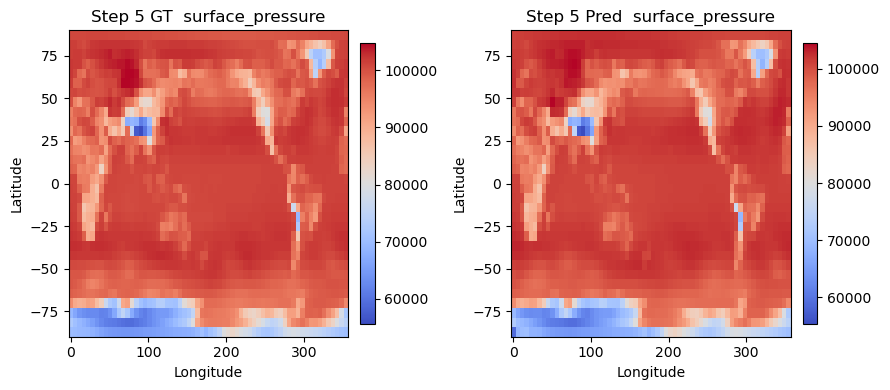

In [35]:
import os, sys, torch, numpy as np, xarray as xr, matplotlib.pyplot as plt
BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
HISTORY_STEPS = 2
STEPS = 5            # autoregressive rollout length (e.g., 5 days)
SAMPLE = 0
PLOT_NORM = False    # False: physical units, True: normalized

PRESSURE_LEVELS = [250,500,850]
PRESSURE_VARS = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS  = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]
VIEW = {
    "temperature_plev250":0,
    "v_wind_plev500":7,
    "surface_pressure":19,
}

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[PRESSURE_VARS[0]].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def acc(pred, gt):
    p = pred - pred.mean(axis=(-2,-1), keepdims=True)
    g = gt   - gt.mean(axis=(-2,-1), keepdims=True)
    num = (p * g).sum(axis=(-2,-1))
    den = np.sqrt((p**2).sum(axis=(-2,-1)) * (g**2).sum(axis=(-2,-1)))
    return num / np.clip(den, 1e-12, None)

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Stats from train
    tr = xr.open_dataset(TRAIN)
    swap_train = needs_swap(tr)
    train_all = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = tr[v].sel(level=lvl).values
            if swap_train: val = np.swapaxes(val, -2, -1)
            train_all.append(val)
    for v in SURFACE_VARS:
        val = tr[v].values
        if swap_train: val = np.swapaxes(val, -2, -1)
        train_all.append(val)
    train_all = np.stack(train_all, 0)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()
    mean_s = mean.squeeze(1); std_s = std.squeeze(1)

    # Load test and coords
    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    if lat_desc: lat = lat[::-1]
    LON, LAT = np.meshgrid(lon, lat)
    swap = needs_swap(te)

    # Build initial history (physical)
    hist_list = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            h = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: h = np.swapaxes(h, -2, -1)
            if lat_desc: h = h[..., ::-1, :]
            hist_list.append(h)
    for v in SURFACE_VARS:
        h = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: h = np.swapaxes(h, -2, -1)
        if lat_desc: h = h[..., ::-1, :]
        hist_list.append(h)
    hist_phys = np.stack(hist_list, 0)  # (C, Hs, H, W)

    # Ground truths for rollout
    gt_steps = []
    for step in range(STEPS):
        g_list = []
        t_idx = SAMPLE + HISTORY_STEPS + step
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                g = te[v].sel(level=lvl).values[t_idx]
                if swap: g = np.swapaxes(g, -2, -1)
                if lat_desc: g = g[..., ::-1, :]
                g_list.append(g)
        for v in SURFACE_VARS:
            g = te[v].values[t_idx]
            if swap: g = np.swapaxes(g, -2, -1)
            if lat_desc: g = g[..., ::-1, :]
            g_list.append(g)
        gt_steps.append(np.stack(g_list, 0))
    te.close()

    # Model
    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=512,
        encoder_dims=(512,768,960),
        swin_depths=(3,4,6),
        swin_heads=(8,12,15),
        swin_window_size=8,
        drop_path_rate=0.15,
        input_height=32, input_width=64,
    ).to(device)
    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    preds_phys = []
    preds_norm = []
    rmse_per_step = []
    mae_per_step = []
    acc_per_step = []

    for step in range(STEPS):
        # normalize history and run model
        hist_n = (hist_phys - mean_s[:,None]) / std_s[:,None]
        h_t = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(h_t)
        pred_n = out[0] if isinstance(out,(list,tuple)) else out
        pred_n = pred_n.squeeze(0).detach().cpu().numpy()  # (C,H,W)
        pred_phys = pred_n * std_s + mean_s

        preds_phys.append(pred_phys)
        preds_norm.append(pred_n)

        gt_step = gt_steps[step]
        gt_norm = (gt_step - mean_s) / std_s

        diff = pred_n - gt_norm
        rmse = np.sqrt((diff**2).mean(axis=(1,2)))
        mae  = np.abs(diff).mean(axis=(1,2))
        accv = acc(pred_n, gt_norm)
        rmse_per_step.append(rmse)
        mae_per_step.append(mae)
        acc_per_step.append(accv)

        print(f"Step {step+1}: RMSE_norm mean={rmse.mean():.3f}, ACC mean={accv.mean():.3f}")

        # update history with predicted physical field
        hist_phys = np.concatenate([hist_phys[:,1:], pred_phys[:,None]], axis=1)

    # Plot GT vs Pred for each step for selected channels
    for step in range(STEPS):
        gt_step = gt_steps[step]
        pr_step = preds_phys[step] if not PLOT_NORM else preds_norm[step]
        gt_plot = gt_step if not PLOT_NORM else (gt_step - mean_s) / std_s
        for name, idx in VIEW.items():
            plt.figure(figsize=(9,4))
            plt.subplot(1,2,1)
            pcm = plt.pcolormesh(LON, LAT, gt_plot[idx], shading="auto", cmap="coolwarm")
            plt.title(f"Step {step+1} GT {'(norm)' if PLOT_NORM else ''} {name}")
            plt.colorbar(pcm, fraction=0.046, pad=0.04)
            plt.xlabel("Longitude"); plt.ylabel("Latitude")
            plt.subplot(1,2,2)
            pcm = plt.pcolormesh(LON, LAT, pr_step[idx], shading="auto", cmap="coolwarm")
            plt.title(f"Step {step+1} Pred {'(norm)' if PLOT_NORM else ''} {name}")
            plt.colorbar(pcm, fraction=0.046, pad=0.04)
            plt.xlabel("Longitude"); plt.ylabel("Latitude")
            plt.tight_layout(); plt.show()

if __name__ == "__main__":
    main()

Using device: cuda


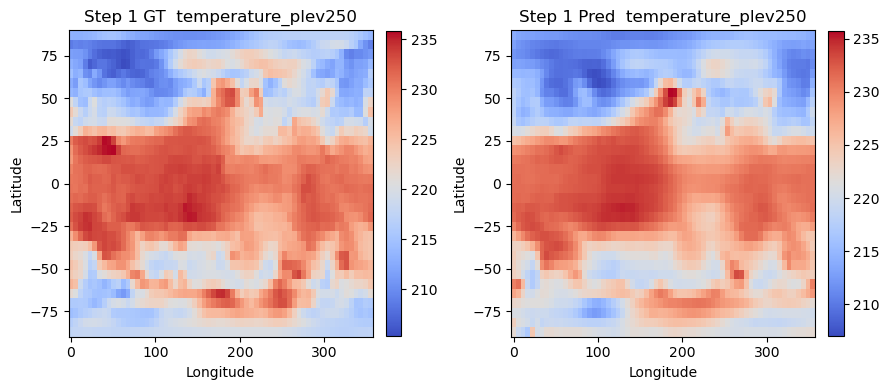

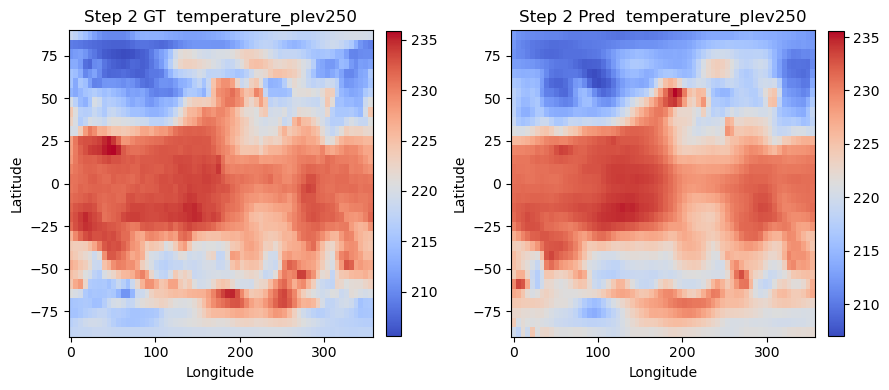

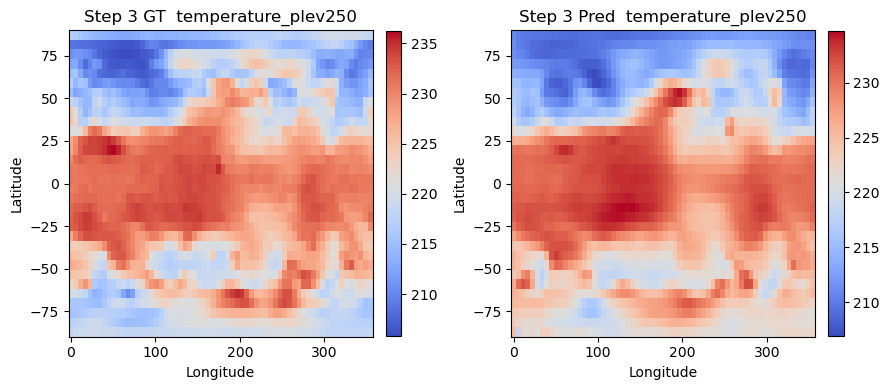

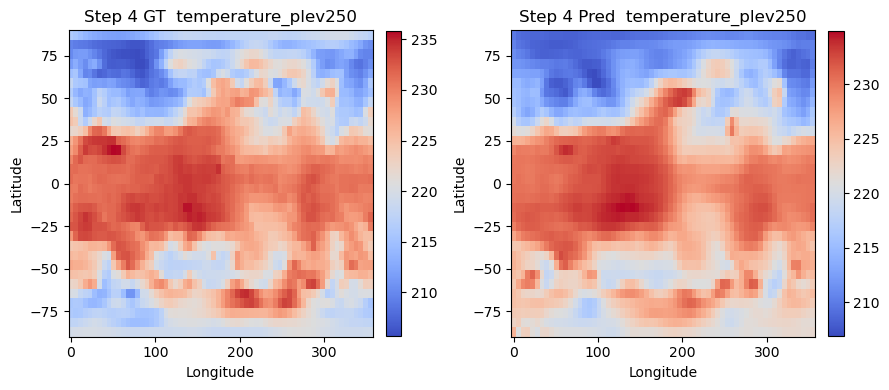

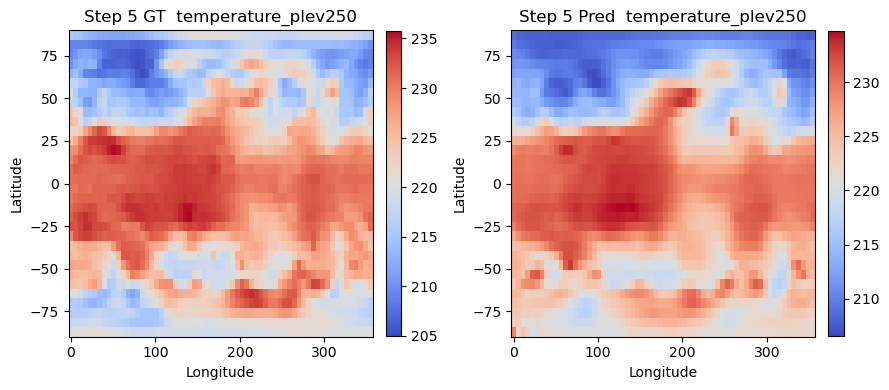

In [37]:
import os, sys, torch, numpy as np, xarray as xr, matplotlib.pyplot as plt
BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
HISTORY_STEPS = 2
STEPS = 5
SAMPLE = 0
PLOT_NORM = False  # False -> physical units, True -> normalized

# Choose variable/channel
VAR = "temperature"
PLEV = 250  # hPa

PRESSURE_LEVELS = [250,500,850]
PRESSURE_VARS = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS  = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]

from fuxi import FuXiModel

def channel_index(var, plev=None):
    if var in PRESSURE_VARS:
        base = PRESSURE_VARS.index(var) * len(PRESSURE_LEVELS)
        return base + PRESSURE_LEVELS.index(plev)
    else:
        return len(PRESSURE_VARS) * len(PRESSURE_LEVELS) + SURFACE_VARS.index(var)

CHAN_IDX = channel_index(VAR, PLEV if VAR in PRESSURE_VARS else None)
VAR_NAME = f"{VAR}_plev{PLEV}" if VAR in PRESSURE_VARS else VAR

def needs_swap(ds):
    dims = ds[VAR].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # stats from train (all 20 channels)
    tr = xr.open_dataset(TRAIN)
    swap_train = needs_swap(tr)
    train_all = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = tr[v].sel(level=lvl).values
            if swap_train: val = np.swapaxes(val, -2, -1)
            train_all.append(val)
    for v in SURFACE_VARS:
        val = tr[v].values
        if swap_train: val = np.swapaxes(val, -2, -1)
        train_all.append(val)
    train_all = np.stack(train_all, 0)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()
    mean_s = mean.squeeze(1); std_s = std.squeeze(1)

    # test data and coords
    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    if lat_desc: lat = lat[::-1]
    LON, LAT = np.meshgrid(lon, lat)
    swap = needs_swap(te)

    # build history (all channels)
    hist=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            h = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: h = np.swapaxes(h, -2, -1)
            if lat_desc: h = h[..., ::-1, :]
            hist.append(h)
    for v in SURFACE_VARS:
        h = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: h = np.swapaxes(h, -2, -1)
        if lat_desc: h = h[..., ::-1, :]
        hist.append(h)
    hist = np.stack(hist, 0)  # (20, Hs, H, W)

    # ground truths for rollout
    gt_steps=[]
    for step in range(STEPS):
        g_list=[]
        t_idx = SAMPLE + HISTORY_STEPS + step
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                g = te[v].sel(level=lvl).values[t_idx]
                if swap: g = np.swapaxes(g, -2, -1)
                if lat_desc: g = g[..., ::-1, :]
                g_list.append(g)
        for v in SURFACE_VARS:
            g = te[v].values[t_idx]
            if swap: g = np.swapaxes(g, -2, -1)
            if lat_desc: g = g[..., ::-1, :]
            g_list.append(g)
        gt_steps.append(np.stack(g_list, 0))
    te.close()

    # model (20 channels to match checkpoint)
    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=512,
        encoder_dims=(512,768,960),
        swin_depths=(3,4,6),
        swin_heads=(8,12,15),
        swin_window_size=8,
        drop_path_rate=0.15,
        input_height=32, input_width=64,
    ).to(device)
    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    preds = []
    for step in range(STEPS):
        hist_n = (hist - mean_s[:,None]) / std_s[:,None]
        x = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(x)
        pred_n = out[0] if isinstance(out,(list,tuple)) else out
        pred_n = pred_n.squeeze(0).detach().cpu().numpy()  # (20,H,W)
        pred_phys = pred_n * std_s + mean_s
        preds.append(pred_phys[CHAN_IDX])
        # roll history with predicted physical full field
        hist = np.concatenate([hist[:,1:], pred_phys[:,None]], axis=1)

    # plot selected channel
    for step in range(STEPS):
        gt_i = gt_steps[step][CHAN_IDX]
        pr_i = preds[step] if not PLOT_NORM else (preds[step]-mean_s[CHAN_IDX])/std_s[CHAN_IDX]
        gt_plot = gt_i if not PLOT_NORM else (gt_i-mean_s[CHAN_IDX])/std_s[CHAN_IDX]
        plt.figure(figsize=(9,4))
        plt.subplot(1,2,1)
        pcm = plt.pcolormesh(LON, LAT, gt_plot, shading="auto", cmap="coolwarm")
        plt.title(f"Step {step+1} GT {'(norm)' if PLOT_NORM else ''} {VAR_NAME}")
        plt.colorbar(pcm, fraction=0.046, pad=0.04)
        plt.xlabel("Longitude"); plt.ylabel("Latitude")
        plt.subplot(1,2,2)
        pcm = plt.pcolormesh(LON, LAT, pr_i, shading="auto", cmap="coolwarm")
        plt.title(f"Step {step+1} Pred {'(norm)' if PLOT_NORM else ''} {VAR_NAME}")
        plt.colorbar(pcm, fraction=0.046, pad=0.04)
        plt.xlabel("Longitude"); plt.ylabel("Latitude")
        plt.tight_layout(); plt.show()

if __name__ == "__main__":
    main()

In [39]:
import os, sys, torch, numpy as np, xarray as xr
BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
HISTORY_STEPS = 2
STEPS = 15
SAMPLE = 0

VAR = "temperature"
PLEV = 250
PRESSURE_LEVELS = [250,500,850]
PRESSURE_VARS = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS  = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[VAR].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def channel_index(var, plev=None):
    if var in PRESSURE_VARS:
        base = PRESSURE_VARS.index(var) * len(PRESSURE_LEVELS)
        return base + PRESSURE_LEVELS.index(plev)
    else:
        return len(PRESSURE_VARS) * len(PRESSURE_LEVELS) + SURFACE_VARS.index(var)

CHAN_IDX = channel_index(VAR, PLEV)

def acc(pred, gt):
    p = pred - pred.mean(axis=(-2,-1), keepdims=True)
    g = gt   - gt.mean(axis=(-2,-1), keepdims=True)
    num = (p * g).sum(axis=(-2,-1))
    den = np.sqrt((p**2).sum(axis=(-2,-1)) * (g**2).sum(axis=(-2,-1)))
    return num / np.clip(den, 1e-12, None)

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # stats
    tr = xr.open_dataset(TRAIN)
    swap_train = needs_swap(tr)
    train_all = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = tr[v].sel(level=lvl).values
            if swap_train: val = np.swapaxes(val, -2, -1)
            train_all.append(val)
    for v in SURFACE_VARS:
        val = tr[v].values
        if swap_train: val = np.swapaxes(val, -2, -1)
        train_all.append(val)
    train_all = np.stack(train_all, 0)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()
    mean_s = mean.squeeze(1); std_s = std.squeeze(1)

    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    swap = needs_swap(te)

    # build history
    hist=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            h = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: h = np.swapaxes(h, -2, -1)
            if lat_desc: h = h[..., ::-1, :]
            hist.append(h)
    for v in SURFACE_VARS:
        h = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: h = np.swapaxes(h, -2, -1)
        if lat_desc: h = h[..., ::-1, :]
        hist.append(h)
    hist = np.stack(hist, 0)

    # gts
    gt_steps=[]
    for step in range(STEPS):
        g_list=[]
        t_idx = SAMPLE + HISTORY_STEPS + step
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                g = te[v].sel(level=lvl).values[t_idx]
                if swap: g = np.swapaxes(g, -2, -1)
                if lat_desc: g = g[..., ::-1, :]
                g_list.append(g)
        for v in SURFACE_VARS:
            g = te[v].values[t_idx]
            if swap: g = np.swapaxes(g, -2, -1)
            if lat_desc: g = g[..., ::-1, :]
            g_list.append(g)
        gt_steps.append(np.stack(g_list, 0))
    te.close()

    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=512,
        encoder_dims=(512,768,960),
        swin_depths=(3,4,6),
        swin_heads=(8,12,15),
        swin_window_size=8,
        drop_path_rate=0.15,
        input_height=32, input_width=64,
    ).to(device)
    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    for step in range(STEPS):
        hist_n = (hist - mean_s[:,None]) / std_s[:,None]
        x = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(x)
        pred_n = out[0] if isinstance(out,(list,tuple)) else out
        pred_n = pred_n.squeeze(0).detach().cpu().numpy()
        pred_phys = pred_n * std_s + mean_s

        gt_step = gt_steps[step]
        gt_norm = (gt_step - mean_s) / std_s

        diff = pred_n[CHAN_IDX] - gt_norm[CHAN_IDX]
        rmse = np.sqrt((diff**2).mean())
        mae  = np.abs(diff).mean()
        accv = acc(pred_n[CHAN_IDX], gt_norm[CHAN_IDX])

        print(f"Step {step+1} {VAR_NAME}: RMSE_norm={rmse:.3f}, MAE_norm={mae:.3f}, ACC={accv:.3f}")

        # roll
        hist = np.concatenate([hist[:,1:], pred_phys[:,None]], axis=1)

if __name__ == "__main__":
    main()

Using device: cuda
Step 1 temperature_plev250: RMSE_norm=0.281, MAE_norm=0.201, ACC=0.948
Step 2 temperature_plev250: RMSE_norm=0.307, MAE_norm=0.221, ACC=0.937
Step 3 temperature_plev250: RMSE_norm=0.342, MAE_norm=0.245, ACC=0.923
Step 4 temperature_plev250: RMSE_norm=0.368, MAE_norm=0.264, ACC=0.913
Step 5 temperature_plev250: RMSE_norm=0.391, MAE_norm=0.281, ACC=0.905
Step 6 temperature_plev250: RMSE_norm=0.406, MAE_norm=0.296, ACC=0.898
Step 7 temperature_plev250: RMSE_norm=0.425, MAE_norm=0.316, ACC=0.890
Step 8 temperature_plev250: RMSE_norm=0.442, MAE_norm=0.334, ACC=0.880
Step 9 temperature_plev250: RMSE_norm=0.469, MAE_norm=0.356, ACC=0.865
Step 10 temperature_plev250: RMSE_norm=0.478, MAE_norm=0.360, ACC=0.857
Step 11 temperature_plev250: RMSE_norm=0.502, MAE_norm=0.377, ACC=0.842
Step 12 temperature_plev250: RMSE_norm=0.514, MAE_norm=0.386, ACC=0.831
Step 13 temperature_plev250: RMSE_norm=0.538, MAE_norm=0.405, ACC=0.816
Step 14 temperature_plev250: RMSE_norm=0.548, MAE_norm

Using device: cuda
Step 1: RMSE=466.687, ACC=0.856
Step 2: RMSE=592.167, ACC=0.823
Step 3: RMSE=758.189, ACC=0.777
Step 4: RMSE=899.687, ACC=0.730
Step 5: RMSE=1041.574, ACC=0.680
Step 6: RMSE=1161.158, ACC=0.630
Step 7: RMSE=1267.641, ACC=0.580
Step 8: RMSE=1362.477, ACC=0.531
Step 9: RMSE=1461.775, ACC=0.481
Step 10: RMSE=1568.589, ACC=0.434
Step 11: RMSE=1672.943, ACC=0.389
Step 12: RMSE=1769.839, ACC=0.341
Step 13: RMSE=1868.266, ACC=0.294
Step 14: RMSE=1947.160, ACC=0.262
Step 15: RMSE=2024.745, ACC=0.238


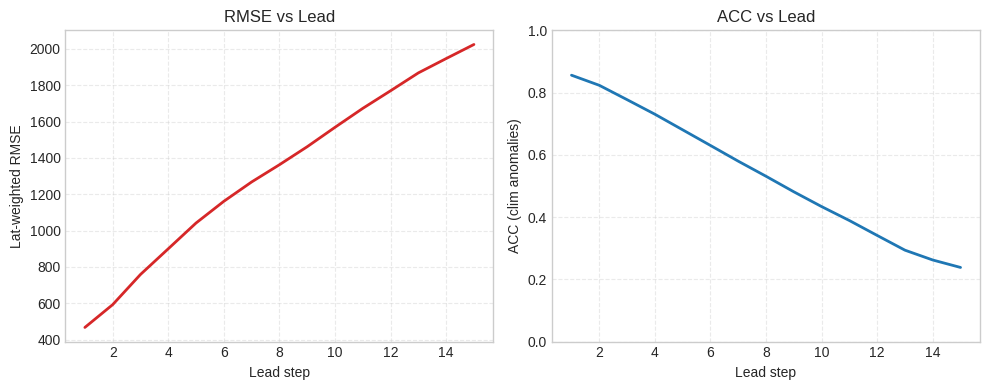

In [41]:
import os, sys, torch, numpy as np, xarray as xr, pandas as pd, matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
CLIM= os.path.join(BASE, "Data/Climatology")
HISTORY_STEPS = 2
STEPS = 15
SAMPLE = 0

PRESSURE_LEVELS = [250,500,850]
PRESSURE_VARS = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS  = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[PRESSURE_VARS[0]].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def lat_weights(lat):
    w = np.cos(np.deg2rad(lat))
    return w / w.sum()

def lat_weighted_rmse(pred, gt, w_lat):
    w = w_lat[None,:,None]
    return np.sqrt((w * (pred-gt)**2).sum(axis=(1,2)))

def lat_weighted_acc(pred, gt, clim, w_lat):
    p = pred - clim
    g = gt   - clim
    w = w_lat[None,:,None]
    num = (w * p * g).sum(axis=(1,2))
    den = np.sqrt((w * p*p).sum(axis=(1,2)) * (w * g*g).sum(axis=(1,2)))
    return num / np.clip(den, 1e-12, None)

def get_clim_slice(clim_ds, var, lvl, hour, doy, swap, lat_desc):
    c = clim_ds[var].sel(hour=hour, dayofyear=doy)
    if lvl is not None:
        c = c.sel(level=lvl)
    arr = c.values
    if swap:
        arr = np.swapaxes(arr, -2, -1)
    if lat_desc:
        arr = arr[..., ::-1, :]
    return arr

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    tr = xr.open_dataset(TRAIN)
    swap_train = needs_swap(tr)
    train_all = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = tr[v].sel(level=lvl).values
            if swap_train: val = np.swapaxes(val, -2, -1)
            train_all.append(val)
    for v in SURFACE_VARS:
        val = tr[v].values
        if swap_train: val = np.swapaxes(val, -2, -1)
        train_all.append(val)
    train_all = np.stack(train_all, 0)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()
    mean_s = mean.squeeze(1); std_s = std.squeeze(1)

    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    if lat_desc: lat = lat[::-1]
    swap = needs_swap(te)
    w_lat = lat_weights(lat)

    hist=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            h = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: h = np.swapaxes(h, -2, -1)
            if lat_desc: h = h[..., ::-1, :]
            hist.append(h)
    for v in SURFACE_VARS:
        h = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: h = np.swapaxes(h, -2, -1)
        if lat_desc: h = h[..., ::-1, :]
        hist.append(h)
    hist = np.stack(hist, 0)

    times = te["time"].values if "time" in te else None
    gt_steps=[]; hours=[]; doys=[]
    for step in range(STEPS):
        g_list=[]; t_idx = SAMPLE + HISTORY_STEPS + step
        if times is not None:
            ts = pd.to_datetime(times[t_idx]); hours.append(int(ts.hour)); doys.append(int(ts.dayofyear))
        else:
            hours.append(0); doys.append(1)
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                g = te[v].sel(level=lvl).values[t_idx]
                if swap: g = np.swapaxes(g, -2, -1)
                if lat_desc: g = g[..., ::-1, :]
                g_list.append(g)
        for v in SURFACE_VARS:
            g = te[v].values[t_idx]
            if swap: g = np.swapaxes(g, -2, -1)
            if lat_desc: g = g[..., ::-1, :]
            g_list.append(g)
        gt_steps.append(np.stack(g_list, 0))
    te.close()

    try:
        clim = xr.open_zarr(CLIM, consolidated=True)
    except Exception:
        clim = xr.open_zarr(CLIM, consolidated=False)

    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=512,
        encoder_dims=(512,768,960),
        swin_depths=(3,4,6),
        swin_heads=(8,12,15),
        swin_window_size=8,
        drop_path_rate=0.15,
        input_height=32, input_width=64,
    ).to(device)
    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    rmse_steps = []; acc_steps = []

    for step in range(STEPS):
        hist_n = (hist - mean_s[:,None]) / std_s[:,None]
        x = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(x)
        pred_n = out[0] if isinstance(out,(list,tuple)) else out
        pred_n = pred_n.squeeze(0).detach().cpu().numpy()
        pred_phys = pred_n * std_s + mean_s
        gt_step = gt_steps[step]

        clim_list=[]
        h = hours[step]; d = doys[step]
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                clim_list.append(get_clim_slice(clim, v, lvl, h, d, swap, lat_desc))
        for v in SURFACE_VARS:
            clim_list.append(get_clim_slice(clim, v, None, h, d, swap, lat_desc))
        clim_arr = np.stack(clim_list, 0)

        rmse_c = lat_weighted_rmse(pred_phys, gt_step, w_lat)
        acc_c  = lat_weighted_acc(pred_phys, gt_step, clim_arr, w_lat)

        rmse_steps.append(rmse_c.mean())
        acc_steps.append(acc_c.mean())

        hist = np.concatenate([hist[:,1:], pred_phys[:,None]], axis=1)

        print(f"Step {step+1}: RMSE={rmse_steps[-1]:.3f}, ACC={acc_steps[-1]:.3f}")

    steps = np.arange(1, STEPS+1)

    fig, ax = plt.subplots(1, 2, figsize=(10,4))
    ax[0].plot(steps, rmse_steps, color="#D62728", lw=2)
    ax[0].set_xlabel("Lead step"); ax[0].set_ylabel("Lat-weighted RMSE")
    ax[0].set_title("RMSE vs Lead"); ax[0].grid(True, ls="--", alpha=0.4)

    ax[1].plot(steps, acc_steps, color="#1F77B4", lw=2)
    ax[1].set_xlabel("Lead step"); ax[1].set_ylabel("ACC (clim anomalies)")
    ax[1].set_ylim(0,1); ax[1].set_title("ACC vs Lead")
    ax[1].grid(True, ls="--", alpha=0.4)

    plt.tight_layout()
    out_dir = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/EvalPlots")
    os.makedirs(out_dir, exist_ok=True)
    plt.savefig(os.path.join(out_dir, "rmse_acc_lead.png"), dpi=300)
    plt.savefig(os.path.join(out_dir, "rmse_acc_lead.svg"))
    plt.show()

if __name__ == "__main__":
    main()

Using device: cuda
Step 1: mean RMSE=466.687, mean ACC=0.856
Step 2: mean RMSE=592.167, mean ACC=0.823
Step 3: mean RMSE=758.189, mean ACC=0.777
Step 4: mean RMSE=899.687, mean ACC=0.730
Step 5: mean RMSE=1041.574, mean ACC=0.680
Step 6: mean RMSE=1161.158, mean ACC=0.630
Step 7: mean RMSE=1267.641, mean ACC=0.580
Step 8: mean RMSE=1362.477, mean ACC=0.531
Step 9: mean RMSE=1461.775, mean ACC=0.481
Step 10: mean RMSE=1568.589, mean ACC=0.434
Step 11: mean RMSE=1672.943, mean ACC=0.389
Step 12: mean RMSE=1769.839, mean ACC=0.341
Step 13: mean RMSE=1868.266, mean ACC=0.294
Step 14: mean RMSE=1947.160, mean ACC=0.262
Step 15: mean RMSE=2024.745, mean ACC=0.238


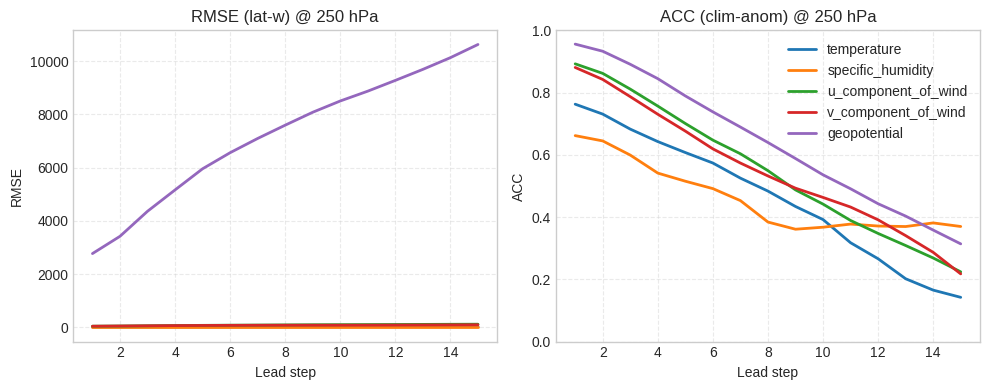

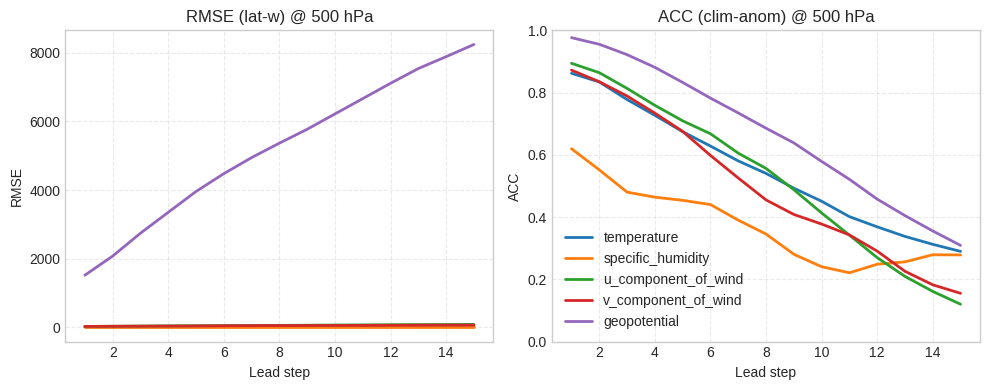

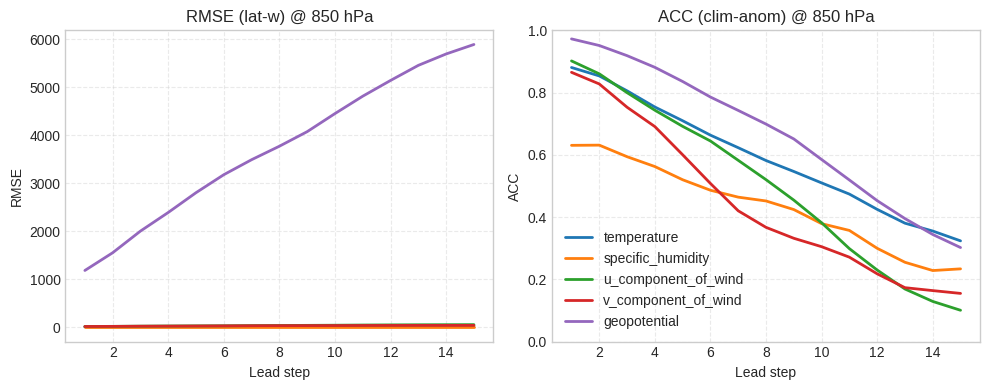

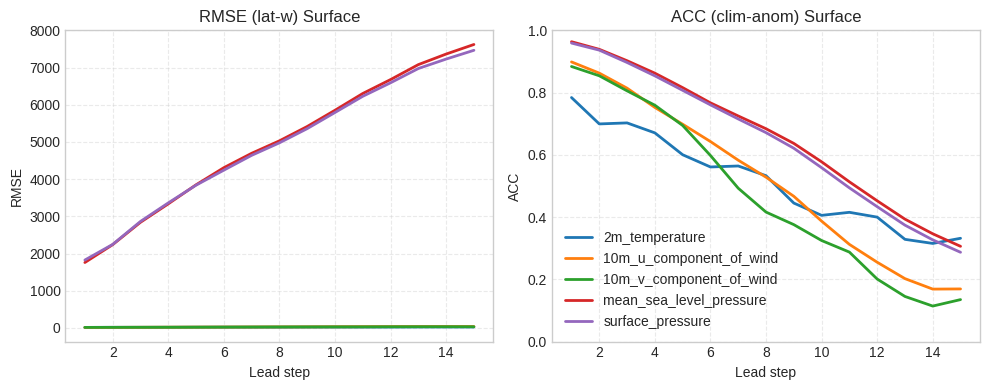

In [42]:
import os, sys, torch, numpy as np, xarray as xr, pandas as pd, matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
CLIM= os.path.join(BASE, "Data/Climatology")
HISTORY_STEPS = 2
STEPS = 15
SAMPLE = 0

PRESSURE_LEVELS = [250, 500, 850]
PRESSURE_VARS   = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS    = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[PRESSURE_VARS[0]].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def lat_weights(lat):
    w = np.cos(np.deg2rad(lat))
    return w / w.sum()

def lat_weighted_rmse(pred, gt, w_lat):
    w = w_lat[None,:,None]
    return np.sqrt((w * (pred-gt)**2).sum(axis=(1,2)))

def lat_weighted_acc(pred, gt, clim, w_lat):
    p = pred - clim
    g = gt   - clim
    w = w_lat[None,:,None]
    num = (w * p * g).sum(axis=(1,2))
    den = np.sqrt((w * p*p).sum(axis=(1,2)) * (w * g*g).sum(axis=(1,2)))
    return num / np.clip(den, 1e-12, None)

def get_clim_slice(clim_ds, var, lvl, hour, doy, swap, lat_desc):
    c = clim_ds[var].sel(hour=hour, dayofyear=doy)
    if lvl is not None:
        c = c.sel(level=lvl)
    arr = c.values
    if swap: arr = np.swapaxes(arr, -2, -1)
    if lat_desc: arr = arr[..., ::-1, :]
    return arr

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    # Train stats (for normalization)
    tr = xr.open_dataset(TRAIN)
    swap_train = needs_swap(tr)
    train_all = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = tr[v].sel(level=lvl).values
            if swap_train: val = np.swapaxes(val, -2, -1)
            train_all.append(val)
    for v in SURFACE_VARS:
        val = tr[v].values
        if swap_train: val = np.swapaxes(val, -2, -1)
        train_all.append(val)
    train_all = np.stack(train_all, 0)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()
    mean_s = mean.squeeze(1); std_s = std.squeeze(1)

    # Test set
    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    if lat_desc: lat = lat[::-1]
    swap = needs_swap(te)
    w_lat = lat_weights(lat)
    times = te["time"].values if "time" in te else None

    # Build history (physical)
    hist=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            h = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: h = np.swapaxes(h, -2, -1)
            if lat_desc: h = h[..., ::-1, :]
            hist.append(h)
    for v in SURFACE_VARS:
        h = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: h = np.swapaxes(h, -2, -1)
        if lat_desc: h = h[..., ::-1, :]
        hist.append(h)
    hist = np.stack(hist, 0)  # (20, Hs, H, W)

    # Ground truth steps
    gt_steps=[]; hours=[]; doys=[]
    for step in range(STEPS):
        g_list=[]; t_idx = SAMPLE + HISTORY_STEPS + step
        if times is not None:
            ts = pd.to_datetime(times[t_idx]); hours.append(int(ts.hour)); doys.append(int(ts.dayofyear))
        else:
            hours.append(0); doys.append(1)
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                g = te[v].sel(level=lvl).values[t_idx]
                if swap: g = np.swapaxes(g, -2, -1)
                if lat_desc: g = g[..., ::-1, :]
                g_list.append(g)
        for v in SURFACE_VARS:
            g = te[v].values[t_idx]
            if swap: g = np.swapaxes(g, -2, -1)
            if lat_desc: g = g[..., ::-1, :]
            g_list.append(g)
        gt_steps.append(np.stack(g_list, 0))
    te.close()

    # Climatology
    try:
        clim = xr.open_zarr(CLIM, consolidated=True)
    except Exception:
        clim = xr.open_zarr(CLIM, consolidated=False)

    # Model
    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=512,
        encoder_dims=(512,768,960),
        swin_depths=(3,4,6),
        swin_heads=(8,12,15),
        swin_window_size=8,
        drop_path_rate=0.15,
        input_height=32, input_width=64,
    ).to(device)
    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    C = len(PRESSURE_VARS)*len(PRESSURE_LEVELS) + len(SURFACE_VARS)
    rmse_mat = np.zeros((STEPS, C), dtype=np.float64)
    acc_mat  = np.zeros((STEPS, C), dtype=np.float64)

    for step in range(STEPS):
        hist_n = (hist - mean_s[:,None]) / std_s[:,None]
        x = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(x)
        pred_n = out[0] if isinstance(out,(list,tuple)) else out
        pred_n = pred_n.squeeze(0).detach().cpu().numpy()
        pred_phys = pred_n * std_s + mean_s
        gt_step = gt_steps[step]

        clim_list=[]
        h = hours[step]; d = doys[step]
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                clim_list.append(get_clim_slice(clim, v, lvl, h, d, swap, lat_desc))
        for v in SURFACE_VARS:
            clim_list.append(get_clim_slice(clim, v, None, h, d, swap, lat_desc))
        clim_arr = np.stack(clim_list, 0)

        rmse_c = lat_weighted_rmse(pred_phys, gt_step, w_lat)
        acc_c  = lat_weighted_acc(pred_phys, gt_step, clim_arr, w_lat)

        rmse_mat[step] = rmse_c
        acc_mat[step]  = acc_c

        hist = np.concatenate([hist[:,1:], pred_phys[:,None]], axis=1)

        print(f"Step {step+1}: mean RMSE={rmse_c.mean():.3f}, mean ACC={acc_c.mean():.3f}")

    # Prepare names by level
    var_names = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            var_names.append(f"{v}@{lvl}hPa")
    for v in SURFACE_VARS:
        var_names.append(v)

    out_dir = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/EvalPlots")
    os.makedirs(out_dir, exist_ok=True)
    steps_arr = np.arange(1, STEPS+1)

    # Plot per pressure level
    for lvl in PRESSURE_LEVELS:
        idxs = []
        labels = []
        for v in PRESSURE_VARS:
            idx = PRESSURE_VARS.index(v)*len(PRESSURE_LEVELS) + PRESSURE_LEVELS.index(lvl)
            idxs.append(idx); labels.append(v)
        fig, ax = plt.subplots(1,2, figsize=(10,4))
        for i,lbl in zip(idxs, labels):
            ax[0].plot(steps_arr, rmse_mat[:, i], lw=2, label=lbl)
            ax[1].plot(steps_arr, acc_mat[:, i],  lw=2, label=lbl)
        ax[0].set_title(f"RMSE (lat-w) @ {lvl} hPa"); ax[0].set_xlabel("Lead step"); ax[0].set_ylabel("RMSE")
        ax[1].set_title(f"ACC (clim-anom) @ {lvl} hPa"); ax[1].set_xlabel("Lead step"); ax[1].set_ylabel("ACC"); ax[1].set_ylim(0,1)
        for a in ax: a.grid(True, ls="--", alpha=0.4)
        ax[1].legend()
        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"rmse_acc_level_{lvl}.png"), dpi=300)
        plt.savefig(os.path.join(out_dir, f"rmse_acc_level_{lvl}.svg"))
        plt.show()

    # Plot surface vars
    surf_start = len(PRESSURE_VARS)*len(PRESSURE_LEVELS)
    surf_idxs = list(range(surf_start, C))
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    for i,lbl in zip(surf_idxs, SURFACE_VARS):
        ax[0].plot(steps_arr, rmse_mat[:, i], lw=2, label=lbl)
        ax[1].plot(steps_arr, acc_mat[:, i],  lw=2, label=lbl)
    ax[0].set_title("RMSE (lat-w) Surface"); ax[0].set_xlabel("Lead step"); ax[0].set_ylabel("RMSE")
    ax[1].set_title("ACC (clim-anom) Surface"); ax[1].set_xlabel("Lead step"); ax[1].set_ylabel("ACC"); ax[1].set_ylim(0,1)
    for a in ax: a.grid(True, ls="--", alpha=0.4)
    ax[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, "rmse_acc_surface.png"), dpi=300)
    plt.savefig(os.path.join(out_dir, "rmse_acc_surface.svg"))
    plt.show()

if __name__ == "__main__":
    main()

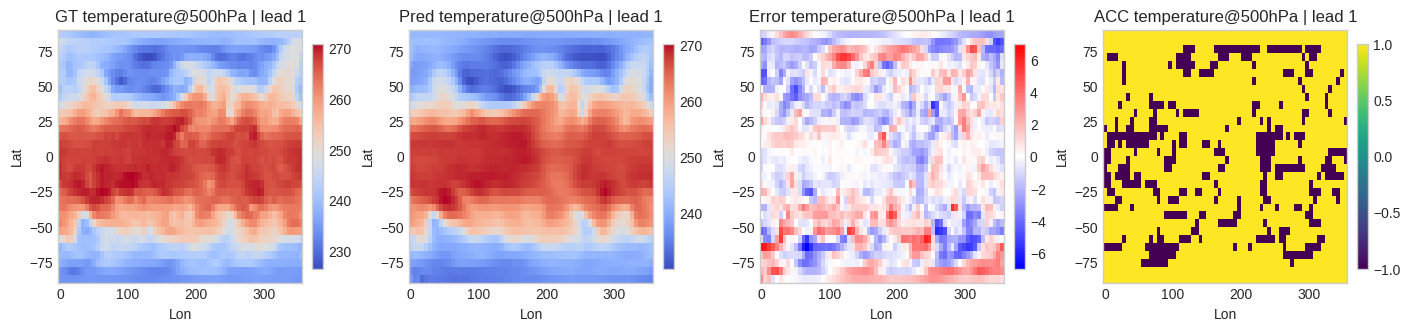

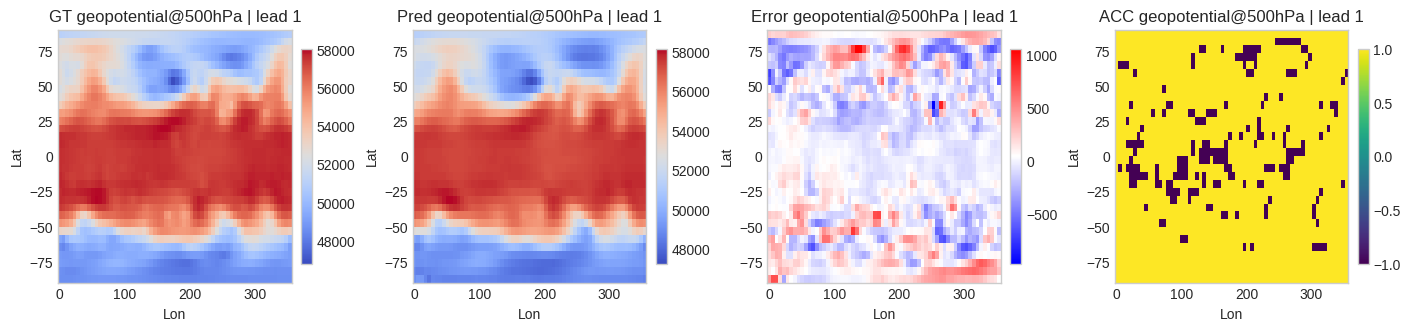

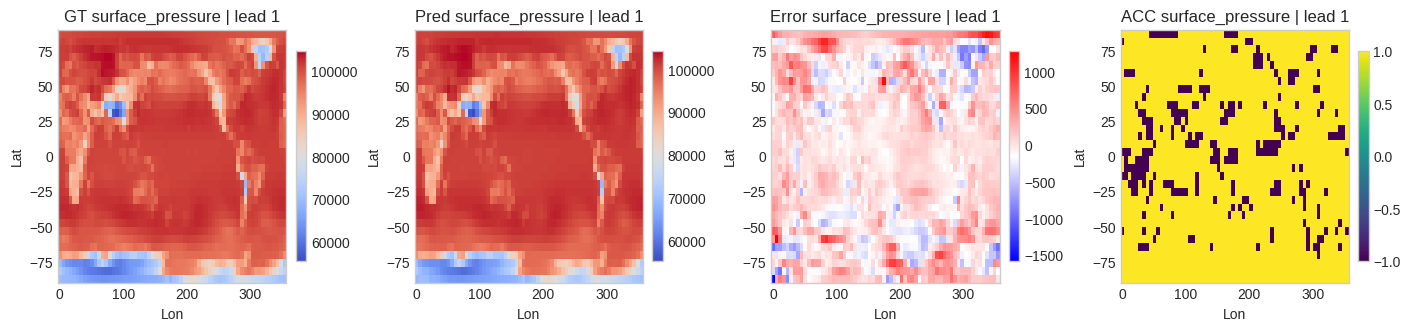

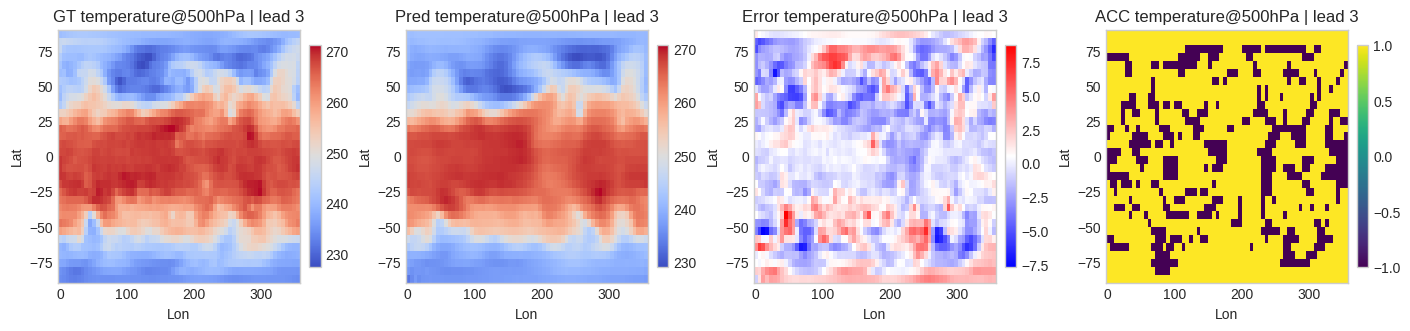

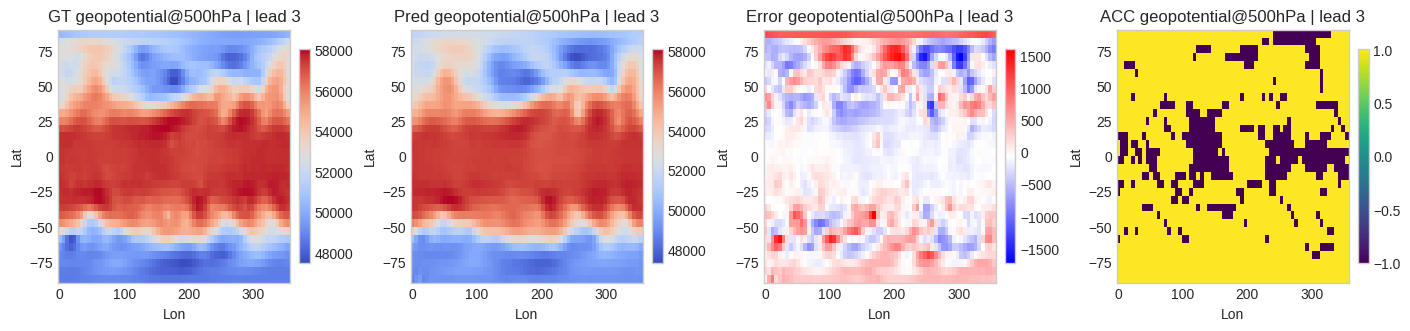

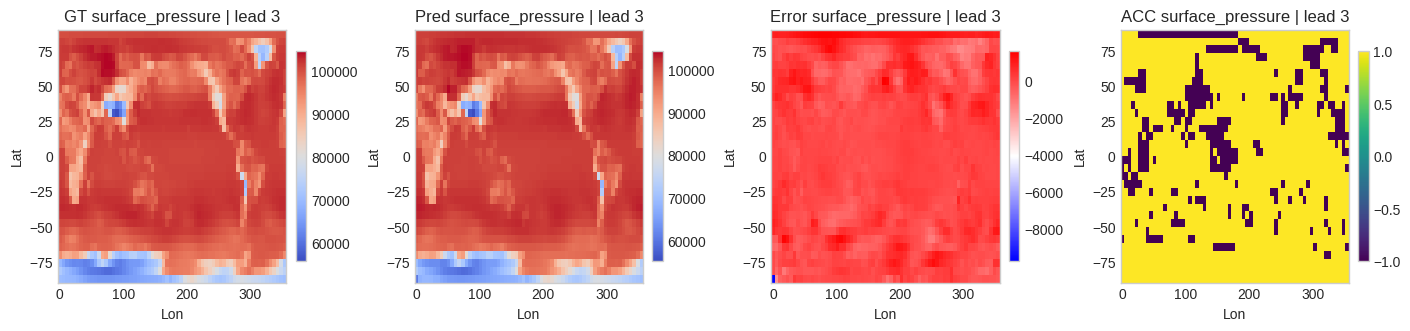

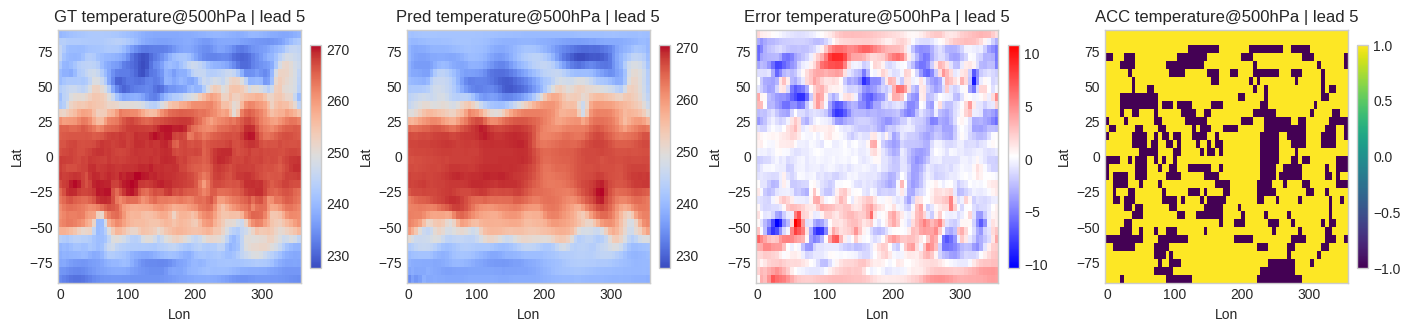

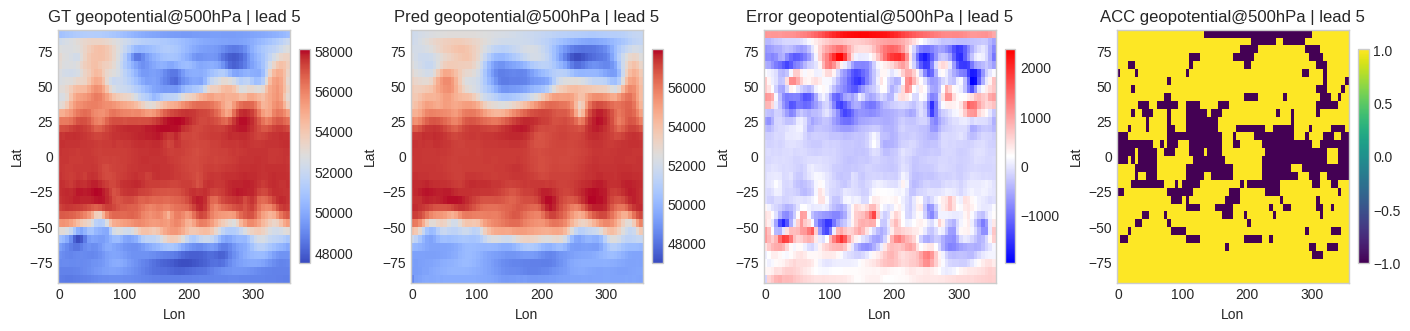

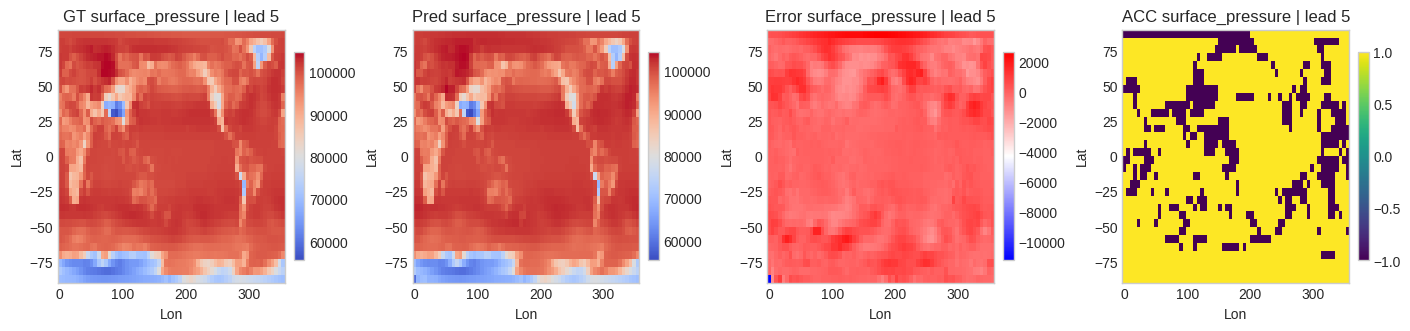

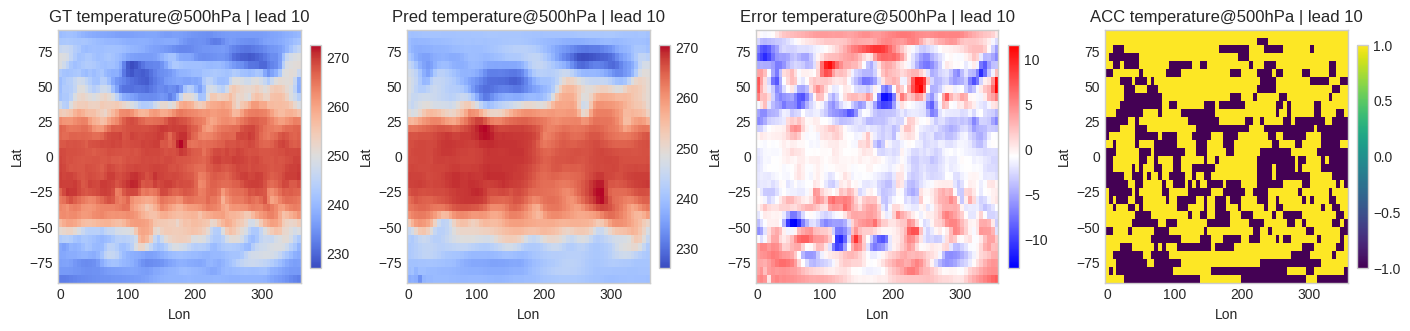

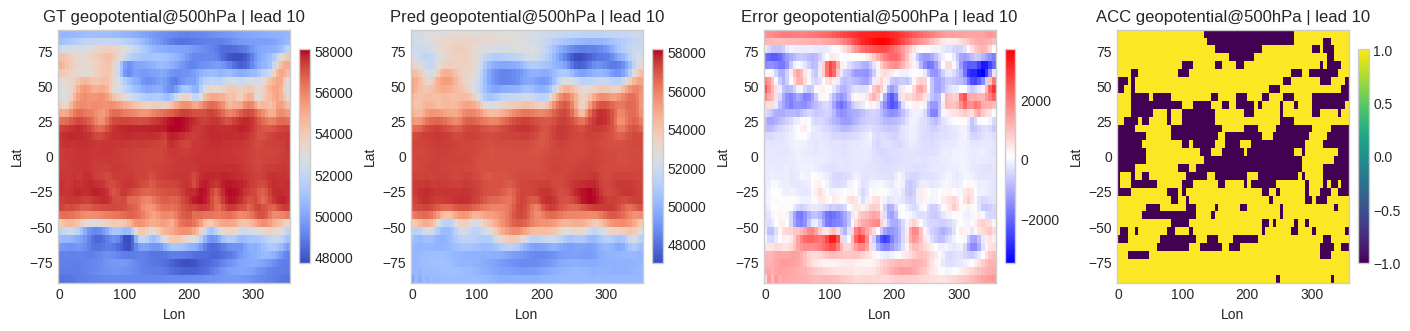

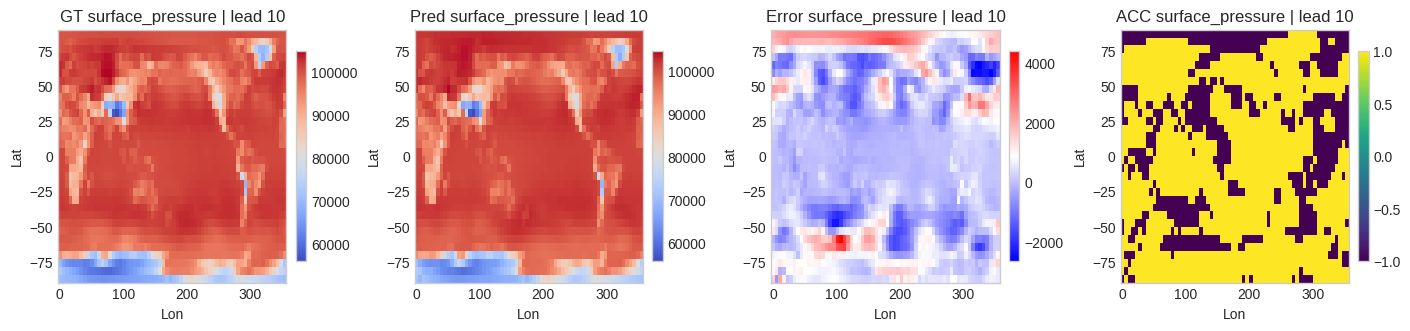

In [43]:
import os, sys, torch, numpy as np, xarray as xr, pandas as pd, matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
BASE = "/home/raj.ayush/New/Fuxi-Weather-Prediction/Fuxi/Fuxi_3P"
sys.path.append(BASE)

CKPT = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/checkpoints/fuxi_epoch023.pt")
TRAIN= os.path.join(BASE, "Data/train_data_1959_2017.nc")
TEST = os.path.join(BASE, "Data/test_data_2021_2023.nc")
CLIM= os.path.join(BASE, "Data/Climatology")
HISTORY_STEPS = 2
STEPS = 10
SAMPLE = 0

PRESSURE_LEVELS = [250,500,850]
PRESSURE_VARS   = ["temperature","specific_humidity","u_component_of_wind","v_component_of_wind","geopotential"]
SURFACE_VARS    = ["2m_temperature","10m_u_component_of_wind","10m_v_component_of_wind","mean_sea_level_pressure","surface_pressure"]

# channels to plot: (name, idx)
CHANNELS_TO_PLOT = [
    ("temperature@500hPa", PRESSURE_VARS.index("temperature")*3 + PRESSURE_LEVELS.index(500)),
    ("geopotential@500hPa", PRESSURE_VARS.index("geopotential")*3 + PRESSURE_LEVELS.index(500)),
    ("surface_pressure", len(PRESSURE_VARS)*len(PRESSURE_LEVELS) + SURFACE_VARS.index("surface_pressure")),
]
LEADS_TO_PLOT = [1, 3, 5, 10]  # 1-based lead steps

from fuxi import FuXiModel

def needs_swap(ds):
    dims = ds[PRESSURE_VARS[0]].dims[-2:]
    return dims in [("longitude","latitude"), ("lon","lat")]

def get_clim_slice(clim_ds, var, lvl, hour, doy, swap, lat_desc):
    c = clim_ds[var].sel(hour=hour, dayofyear=doy)
    if lvl is not None: c = c.sel(level=lvl)
    arr = c.values
    if swap: arr = np.swapaxes(arr, -2, -1)
    if lat_desc: arr = arr[..., ::-1, :]
    return arr

def grid_acc(pred, gt, clim):
    p = pred - clim
    g = gt   - clim
    num = (p * g)
    den = np.sqrt((p*p) * (g*g))
    return num / np.clip(den, 1e-12, None)

def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tr = xr.open_dataset(TRAIN)
    swap_train = needs_swap(tr)
    train_all = []
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            val = tr[v].sel(level=lvl).values
            if swap_train: val = np.swapaxes(val, -2, -1)
            train_all.append(val)
    for v in SURFACE_VARS:
        val = tr[v].values
        if swap_train: val = np.swapaxes(val, -2, -1)
        train_all.append(val)
    train_all = np.stack(train_all, 0)
    mean = train_all.mean(axis=(1,2,3), keepdims=True).astype(np.float32)
    std  = train_all.std(axis=(1,2,3), keepdims=True).clip(min=1e-6).astype(np.float32)
    tr.close()
    mean_s = mean.squeeze(1); std_s = std.squeeze(1)

    te = xr.open_dataset(TEST)
    lat = te["latitude" if "latitude" in te.dims else "lat"].values
    lon = te["longitude" if "longitude" in te.dims else "lon"].values
    lat_desc = lat[0] > lat[-1]
    if lat_desc: lat = lat[::-1]
    LON, LAT = np.meshgrid(lon, lat)
    swap = needs_swap(te)
    times = te["time"].values if "time" in te else None

    # history
    hist=[]
    for v in PRESSURE_VARS:
        for lvl in PRESSURE_LEVELS:
            h = te[v].sel(level=lvl).values[SAMPLE:SAMPLE+HISTORY_STEPS]
            if swap: h = np.swapaxes(h, -2, -1)
            if lat_desc: h = h[..., ::-1, :]
            hist.append(h)
    for v in SURFACE_VARS:
        h = te[v].values[SAMPLE:SAMPLE+HISTORY_STEPS]
        if swap: h = np.swapaxes(h, -2, -1)
        if lat_desc: h = h[..., ::-1, :]
        hist.append(h)
    hist = np.stack(hist, 0)

    # GT steps and time info
    gt_steps=[]; hours=[]; doys=[]
    for step in range(STEPS):
        g_list=[]; t_idx = SAMPLE + HISTORY_STEPS + step
        if times is not None:
            ts = pd.to_datetime(times[t_idx]); hours.append(int(ts.hour)); doys.append(int(ts.dayofyear))
        else:
            hours.append(0); doys.append(1)
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                g = te[v].sel(level=lvl).values[t_idx]
                if swap: g = np.swapaxes(g, -2, -1)
                if lat_desc: g = g[..., ::-1, :]
                g_list.append(g)
        for v in SURFACE_VARS:
            g = te[v].values[t_idx]
            if swap: g = np.swapaxes(g, -2, -1)
            if lat_desc: g = g[..., ::-1, :]
            g_list.append(g)
        gt_steps.append(np.stack(g_list, 0))
    te.close()

    # climatology
    try:
        clim = xr.open_zarr(CLIM, consolidated=True)
    except Exception:
        clim = xr.open_zarr(CLIM, consolidated=False)

    # model
    model = FuXiModel(
        in_channels=20, out_channels=20,
        embed_dim=512,
        encoder_dims=(512,768,960),
        swin_depths=(3,4,6),
        swin_heads=(8,12,15),
        swin_window_size=8,
        drop_path_rate=0.15,
        input_height=32, input_width=64,
    ).to(device)
    sd = torch.load(CKPT, map_location=device)["model_state"]
    sd = {k.replace("module.","",1): v for k,v in sd.items()}
    model.load_state_dict(sd)
    model.eval()

    out_dir = os.path.join(BASE, "Models/exp_FuXi3Stage_20251118_005002/EvalPlots")
    os.makedirs(out_dir, exist_ok=True)

    for step in range(STEPS):
        hist_n = (hist - mean_s[:,None]) / std_s[:,None]
        x = torch.from_numpy(hist_n).float().unsqueeze(0).to(device)
        with torch.no_grad():
            out = model(x)
        pred_n = out[0] if isinstance(out,(list,tuple)) else out
        pred_n = pred_n.squeeze(0).detach().cpu().numpy()
        pred_phys = pred_n * std_s + mean_s
        gt_step = gt_steps[step]

        # roll
        hist = np.concatenate([hist[:,1:], pred_phys[:,None]], axis=1)

        if (step+1) not in LEADS_TO_PLOT:
            continue

        # time keys for clim
        h = hours[step]; d = doys[step]
        clim_list=[]
        for v in PRESSURE_VARS:
            for lvl in PRESSURE_LEVELS:
                clim_list.append(get_clim_slice(clim, v, lvl, h, d, swap, lat_desc))
        for v in SURFACE_VARS:
            clim_list.append(get_clim_slice(clim, v, None, h, d, swap, lat_desc))
        clim_arr = np.stack(clim_list, 0)

        for name, idx in CHANNELS_TO_PLOT:
            gt_i = gt_step[idx]
            pr_i = pred_phys[idx]
            err_i = pr_i - gt_i
            acc_i = grid_acc(pr_i, gt_i, clim_arr[idx])

            fig, axes = plt.subplots(1,4, figsize=(14,3.2), constrained_layout=True)
            for ax, data, title, cmap in [
                (axes[0], gt_i,  f"GT {name}", "coolwarm"),
                (axes[1], pr_i,  f"Pred {name}", "coolwarm"),
                (axes[2], err_i, f"Error {name}", "bwr"),
                (axes[3], acc_i, f"ACC {name}", "viridis"),
            ]:
                pcm = ax.pcolormesh(LON, LAT, data, shading="auto", cmap=cmap)
                fig.colorbar(pcm, ax=ax, fraction=0.046, pad=0.04)
                ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
                ax.set_title(f"{title} | lead {step+1}")
            fname = os.path.join(out_dir, f"maps_lead{step+1}_{name.replace('@','_')}.png")
            #plt.savefig(fname, dpi=300)
            plt.show()

if __name__ == "__main__":
    main()